# Hyperparameter Grid Search Results Visualization

This notebook provides comprehensive visualizations for hyperparameter grid search results, including:
1. Correlation matrices between configurations and metrics
2. Pairwise configuration scatter plots with metric coloring
3. Individual metric vs configuration scatter plots

Data is split by `no_si` values (0 and 1) as metrics across different `no_si` values are not comparable.

## 1. Import Required Libraries

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
import warnings

# Set up plotting parameters
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10
sns.set_palette("husl")

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load and Explore Data

In [27]:
# Load the data
data_path = r'hyperparameter_search_results.csv'
df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst few rows:")
df.head()

Dataset shape: (1944, 17)

Column names:
['sample_id', 'y_type', 'no_si', 'val_loss', 'val_mape%', 'val_rate_bits', 'val_real_bit_r', 'val_mse', 'cnfg_inp_dim', 'cnfg_num_planes', 'cnfg_bins_per_plane', 'cnfg_lr', 'cnfg_tau', 'cnfg_reconst_ld', 'cnfg_train_sample_size', 'cnfg_epochs', 'cnfg_batch_size']

First few rows:


,sample_id,y_type,no_si,val_loss,val_mape%,val_rate_bits,val_real_bit_r,val_mse,cnfg_inp_dim,cnfg_num_planes,cnfg_bins_per_plane,cnfg_lr,cnfg_tau,cnfg_reconst_ld,cnfg_train_sample_size,cnfg_epochs,cnfg_batch_size
0,config_0_sample_0,normal_dist,1,3.777367,90.940804,1.808221,3.521108,0.001523,1,3,4,0.001,1.0,50.0,100000,25,1000
1,config_0_sample_0,normal_dist,1,3.675180,103.810516,1.818663,3.398499,0.001445,1,3,4,0.001,1.0,50.0,100000,25,1000
2,config_0_sample_0,normal_dist,1,3.775462,85.334084,1.804618,3.530444,0.001466,1,3,4,0.001,1.0,50.0,100000,25,1000
3,config_0_sample_0,normal_dist,1,3.801371,144.580963,1.807695,3.532051,0.001481,1,3,4,0.001,1.0,50.0,100000,25,1000
4,config_0_sample_1,normal_dist,1,3.965153,126.321770,1.914834,3.322683,0.001002,1,3,4,0.001,1.0,50.0,100000,25,1000


In [28]:
# Explore data types and basic statistics
print("Data types:")
print(df.dtypes)

print("\nBasic statistics:")
df.describe()

print("\nUnique values in no_si:")
print(df['no_si'].value_counts())

print("\nMissing values:")
print(df.isnull().sum())

Data types:
sample_id                  object
y_type                     object
no_si                       int64
val_loss                  float64
val_mape%                 float64
val_rate_bits             float64
val_real_bit_r            float64
val_mse                   float64
cnfg_inp_dim                int64
cnfg_num_planes             int64
cnfg_bins_per_plane         int64
cnfg_lr                   float64
cnfg_tau                  float64
cnfg_reconst_ld           float64
cnfg_train_sample_size      int64
cnfg_epochs                 int64
cnfg_batch_size             int64
dtype: object

Basic statistics:

Unique values in no_si:
no_si
1    972
0    972
Name: count, dtype: int64

Missing values:
sample_id                 0
y_type                    0
no_si                     0
val_loss                  0
val_mape%                 0
val_rate_bits             0
val_real_bit_r            0
val_mse                   0
cnfg_inp_dim              0
cnfg_num_planes           0
cnfg_

## 3. Data Preprocessing and Filtering

In [29]:
# Identify metric and configuration columns
metric_cols = [col for col in df.columns if col.startswith('val_')]
all_config_cols = [col for col in df.columns if col.startswith('cnfg_')]

print("All configuration columns:", all_config_cols)
print("Metric columns:", metric_cols)

# Filter out configuration columns that don't vary (same value for all rows)
varying_config_cols = []
for col in all_config_cols:
    unique_values = df[col].nunique()
    if unique_values > 1:
        varying_config_cols.append(col)
        print(f"{col}: {unique_values} unique values")
    else:
        print(f"{col}: {unique_values} unique value (CONSTANT - excluding from analysis)")

config_cols = varying_config_cols
print(f"\nFinal configuration columns for analysis: {config_cols}")

# Split data by no_si values
df_no_si_0 = df[df['no_si'] == 0].copy()
df_no_si_1 = df[df['no_si'] == 1].copy()

print(f"\nData split:")
print(f"no_si == 0: {len(df_no_si_0)} rows")
print(f"no_si == 1: {len(df_no_si_1)} rows")

# Create separate dataframes for analysis with only varying configs
metrics_0 = df_no_si_0[metric_cols]
configs_0 = df_no_si_0[config_cols]

metrics_1 = df_no_si_1[metric_cols]
configs_1 = df_no_si_1[config_cols]

print(f"\nConfiguration columns that vary within each no_si group:")
for col in config_cols:
    unique_vals_0 = df_no_si_0[col].nunique() if col in df_no_si_0.columns else 0
    unique_vals_1 = df_no_si_1[col].nunique() if col in df_no_si_1.columns else 0
    print(f"{col}: {unique_vals_0} unique values (no_si=0), {unique_vals_1} unique values (no_si=1)")

All configuration columns: ['cnfg_inp_dim', 'cnfg_num_planes', 'cnfg_bins_per_plane', 'cnfg_lr', 'cnfg_tau', 'cnfg_reconst_ld', 'cnfg_train_sample_size', 'cnfg_epochs', 'cnfg_batch_size']
Metric columns: ['val_loss', 'val_mape%', 'val_rate_bits', 'val_real_bit_r', 'val_mse']
cnfg_inp_dim: 1 unique value (CONSTANT - excluding from analysis)
cnfg_num_planes: 1 unique value (CONSTANT - excluding from analysis)
cnfg_bins_per_plane: 1 unique value (CONSTANT - excluding from analysis)
cnfg_lr: 3 unique values
cnfg_tau: 3 unique values
cnfg_reconst_ld: 3 unique values
cnfg_train_sample_size: 1 unique value (CONSTANT - excluding from analysis)
cnfg_epochs: 1 unique value (CONSTANT - excluding from analysis)
cnfg_batch_size: 3 unique values

Final configuration columns for analysis: ['cnfg_lr', 'cnfg_tau', 'cnfg_reconst_ld', 'cnfg_batch_size']

Data split:
no_si == 0: 972 rows
no_si == 1: 972 rows

Configuration columns that vary within each no_si group:
cnfg_lr: 3 unique values (no_si=0), 3 un

### 3.1 Select Representative Rows by Median MAPE%

Before visualization, we'll select one representative row for each `sample_id` by choosing the row with the median `val_mape%` value within each sample group.

In [30]:
def get_median_row_per_sample(dataframe):
    """
    For each sample_id, return the row with the median val_mape% value
    """
    median_rows = []
    
    for sample_id in dataframe['sample_id'].unique():
        sample_data = dataframe[dataframe['sample_id'] == sample_id].copy()
        
        # Find the row with median val_mape%
        if len(sample_data) == 1:
            median_row = sample_data.iloc[0]
        else:
            # Calculate median val_mape% for this sample
            median_mape = sample_data['val_mape%'].median()
            
            # Find the row closest to the median
            closest_idx = (sample_data['val_mape%'] - median_mape).abs().idxmin()
            median_row = sample_data.loc[closest_idx]
        
        median_rows.append(median_row)
    
    return pd.DataFrame(median_rows)

print("Original data shape:", df.shape)
print("Unique sample_ids:", df['sample_id'].nunique())

# Get median rows for the entire dataset
df_median = get_median_row_per_sample(df)

print("After selecting median rows:", df_median.shape)
print("Sample_ids in median dataset:", df_median['sample_id'].nunique())

# Show examples of the selection process
print("\nExample: Rows for first sample_id:")
first_sample = df['sample_id'].iloc[0]
sample_rows = df[df['sample_id'] == first_sample]
print(f"Sample ID: {first_sample}")
print(f"Original rows: {len(sample_rows)}")
print(f"val_mape% values: {sample_rows['val_mape%'].tolist()}")
print(f"Median val_mape%: {sample_rows['val_mape%'].median()}")
selected_row = df_median[df_median['sample_id'] == first_sample]
print(f"Selected val_mape%: {selected_row['val_mape%'].iloc[0]}")

# Update the split datasets with median rows
df_no_si_0 = df_median[df_median['no_si'] == 0].copy()
df_no_si_1 = df_median[df_median['no_si'] == 1].copy()

print(f"\nUpdated data split:")
print(f"no_si == 0: {len(df_no_si_0)} rows")
print(f"no_si == 1: {len(df_no_si_1)} rows")

# Update separate dataframes for analysis with only varying configs
metrics_0 = df_no_si_0[metric_cols]
configs_0 = df_no_si_0[config_cols]

metrics_1 = df_no_si_1[metric_cols]
configs_1 = df_no_si_1[config_cols]

print(f"\nFinal configuration columns that vary within each no_si group:")
for col in config_cols:
    unique_vals_0 = df_no_si_0[col].nunique() if col in df_no_si_0.columns else 0
    unique_vals_1 = df_no_si_1[col].nunique() if col in df_no_si_1.columns else 0
    print(f"{col}: {unique_vals_0} unique values (no_si=0), {unique_vals_1} unique values (no_si=1)")

Original data shape: (1944, 17)
Unique sample_ids: 486
After selecting median rows: (486, 17)
Sample_ids in median dataset: 486

Example: Rows for first sample_id:
Sample ID: config_0_sample_0
Original rows: 4
val_mape% values: [90.94080352783205, 103.81051635742188, 85.3340835571289, 144.58096313476562]
Median val_mape%: 97.37565994262695
Selected val_mape%: 90.94080352783205

Updated data split:
no_si == 0: 243 rows
no_si == 1: 243 rows

Final configuration columns that vary within each no_si group:
cnfg_lr: 3 unique values (no_si=0), 3 unique values (no_si=1)
cnfg_tau: 3 unique values (no_si=0), 3 unique values (no_si=1)
cnfg_reconst_ld: 3 unique values (no_si=0), 3 unique values (no_si=1)
cnfg_batch_size: 3 unique values (no_si=0), 3 unique values (no_si=1)


## 4. Correlation Matrix: Configuration vs Metrics

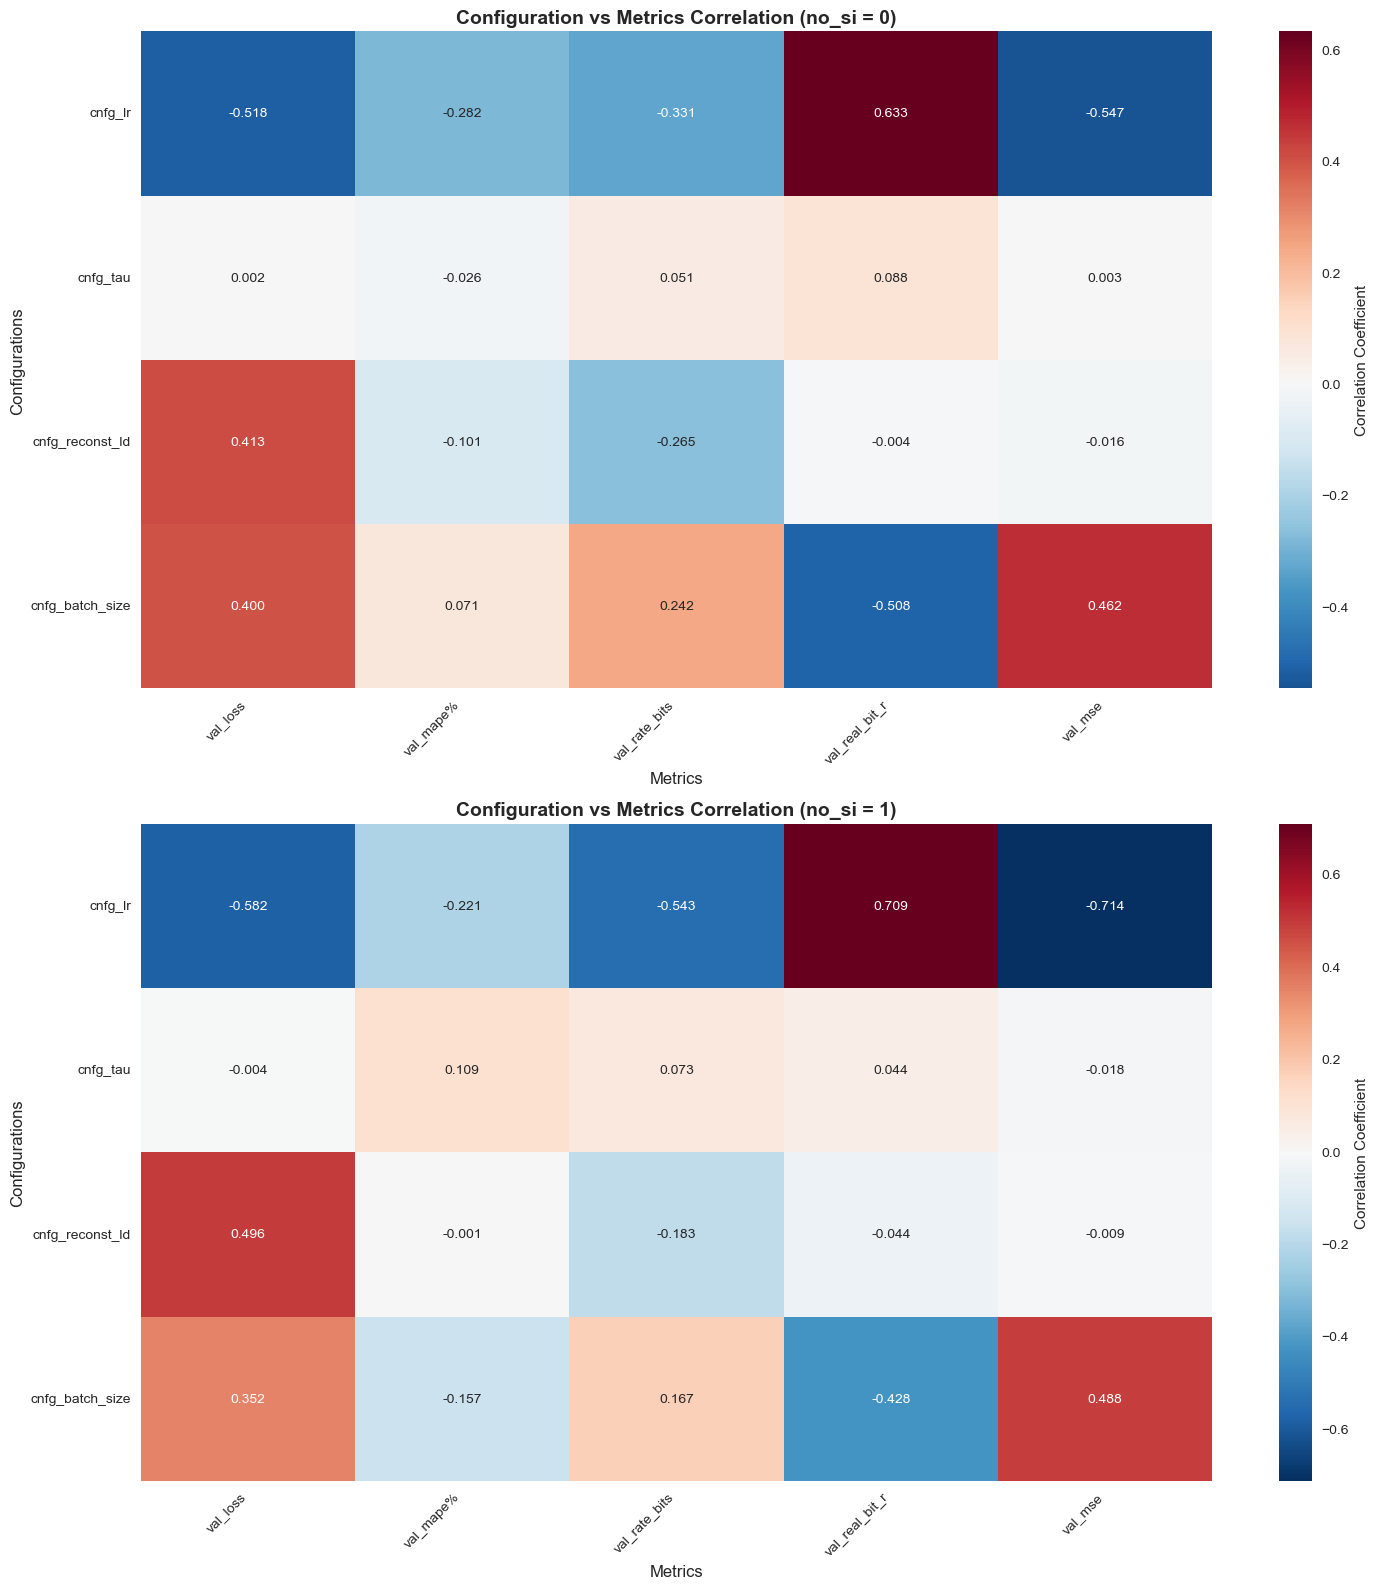

In [31]:
def create_correlation_matrix(configs, metrics, title, ax):
    """Create correlation matrix between configurations and metrics"""
    if len(config_cols) == 0:
        ax.text(0.5, 0.5, 'No varying configuration\ncolumns found', 
                ha='center', va='center', transform=ax.transAxes, fontsize=14)
        ax.set_title(title, fontsize=14, fontweight='bold')
        return
    
    # Combine configs and metrics for correlation calculation
    combined_data = pd.concat([configs, metrics], axis=1)
    
    # Calculate correlation matrix between configs and metrics only
    corr_matrix = combined_data[config_cols + metric_cols].corr()
    
    # Extract the config-metric correlations
    config_metric_corr = corr_matrix.loc[config_cols, metric_cols]

    # Create heatmap
    sns.heatmap(config_metric_corr,
                annot=True,
                cmap='RdBu_r',
                center=0, 
                fmt='.3f',
                ax=ax,
                cbar_kws={'label': 'Correlation Coefficient'})

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Metrics', fontsize=12)
    ax.set_ylabel('Configurations', fontsize=12)
    
    # Rotate labels for better readability
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

# Create correlation matrices
fig, axes = plt.subplots(2, 1, figsize=(15, 16))

create_correlation_matrix(configs_0, metrics_0, 'Configuration vs Metrics Correlation (no_si = 0)', axes[0])
create_correlation_matrix(configs_1, metrics_1, 'Configuration vs Metrics Correlation (no_si = 1)', axes[1])

plt.tight_layout()
plt.show()

## 5. Pairwise Configuration Scatter Plots with Metric Coloring

Creating pairwise scatter plots for no_si = 0...
Found 6 configuration pairs for no_si = 0: ['cnfg_lr', 'cnfg_tau', 'cnfg_reconst_ld', 'cnfg_batch_size']


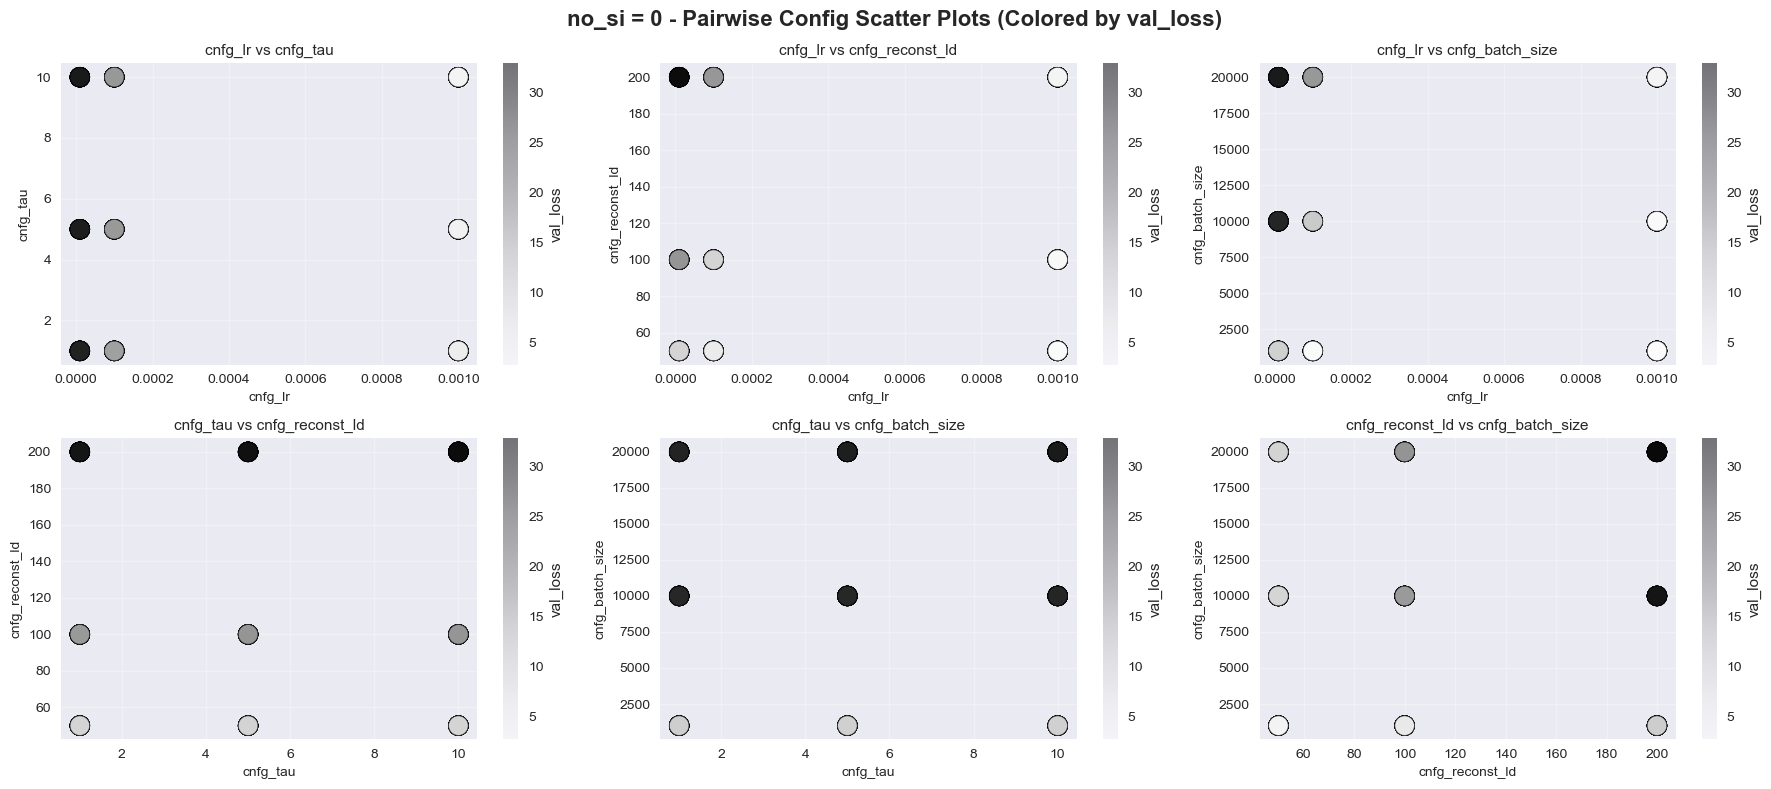

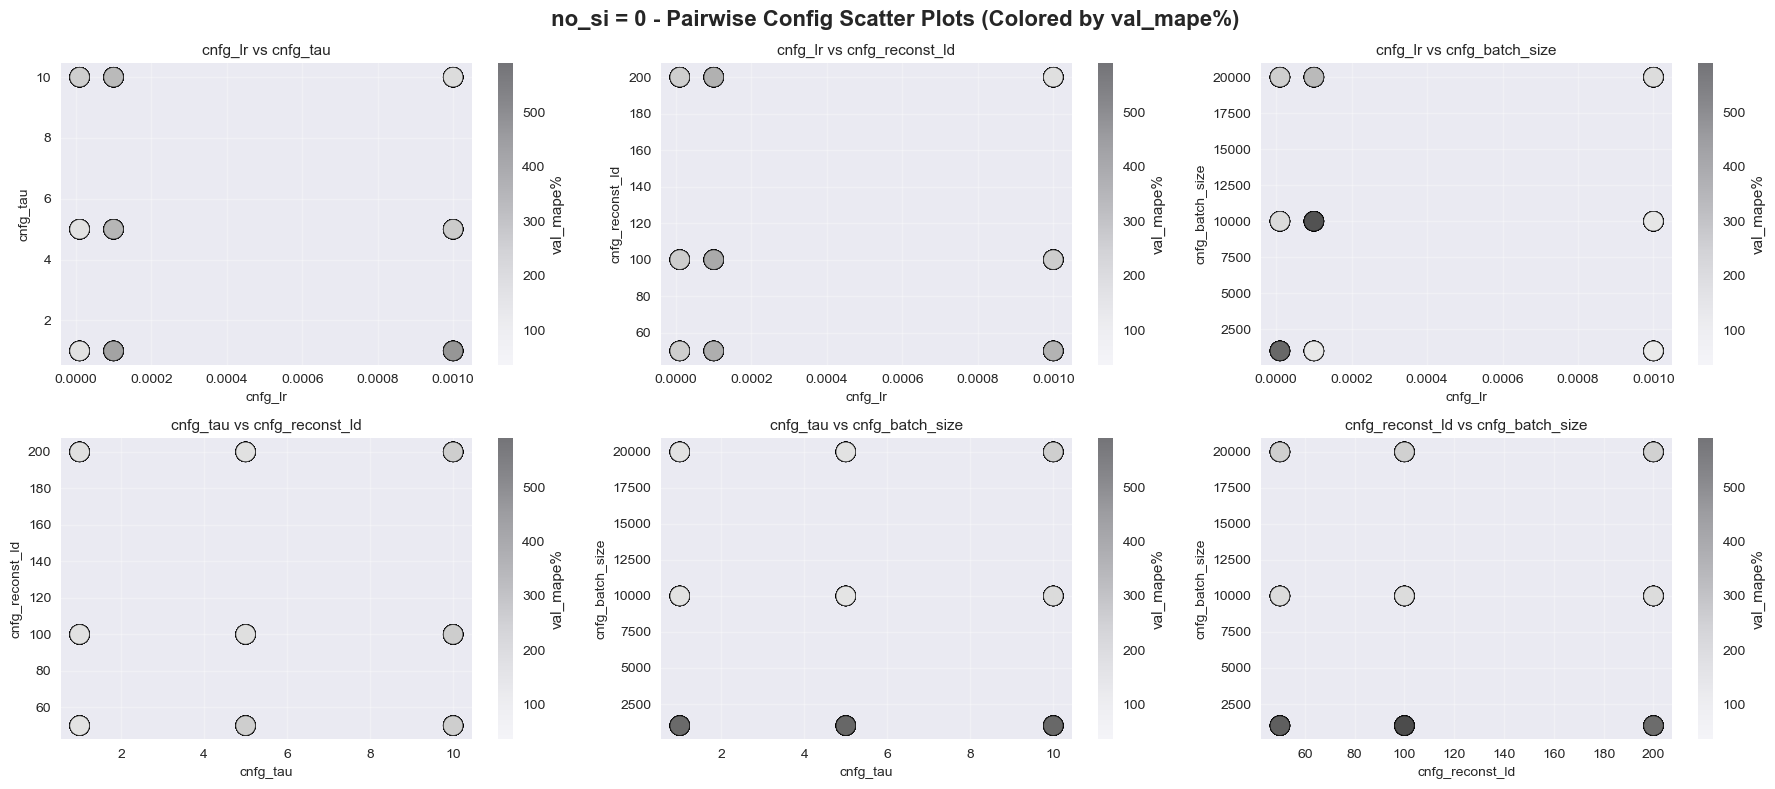

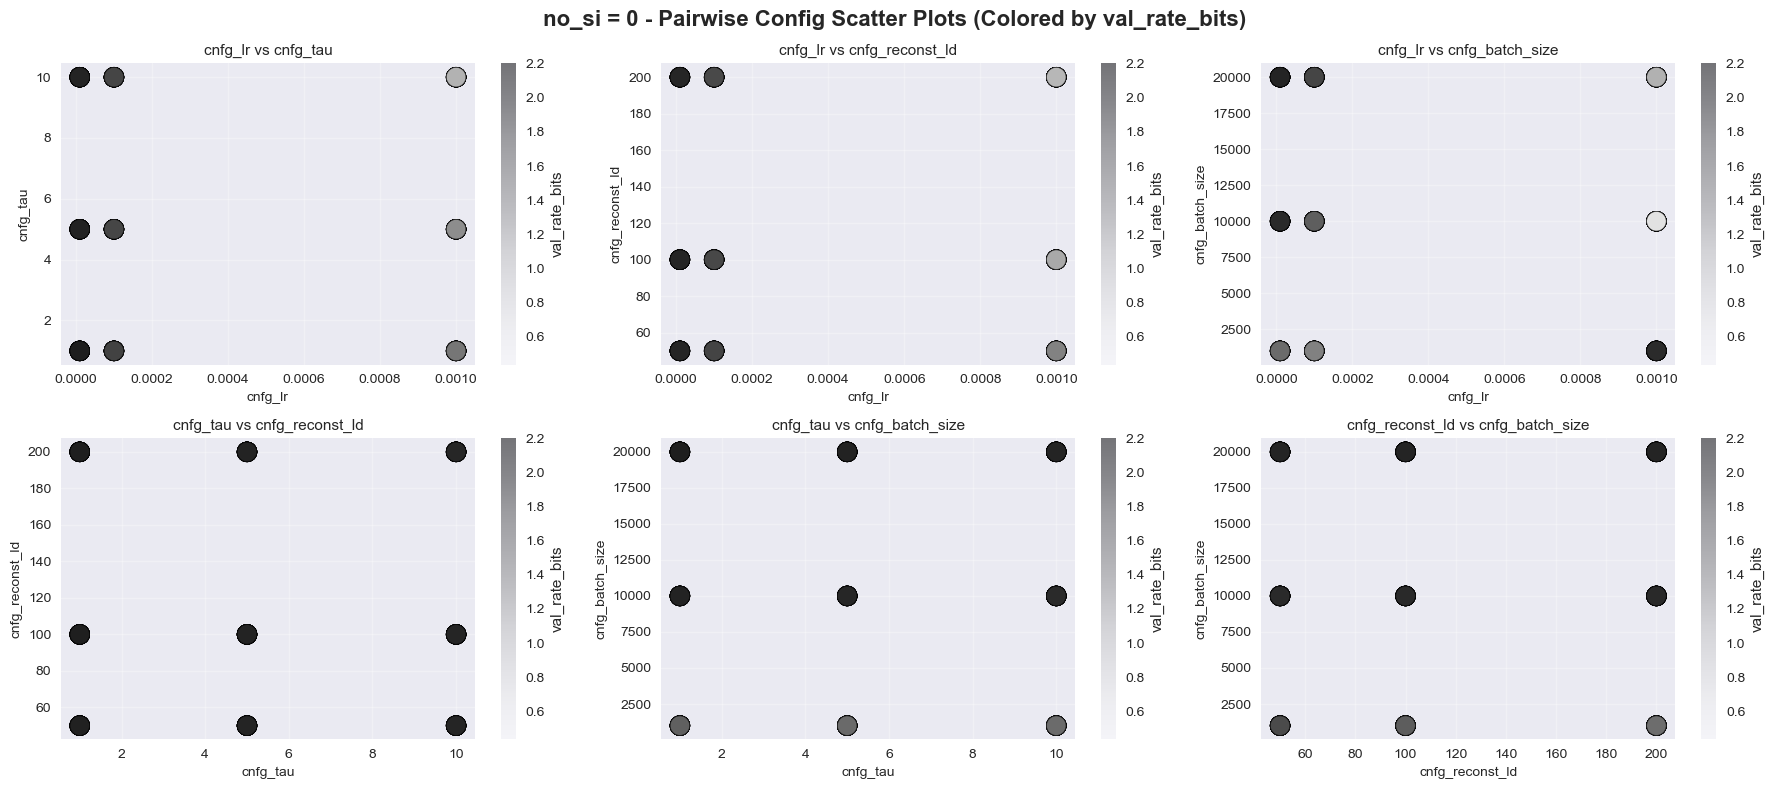

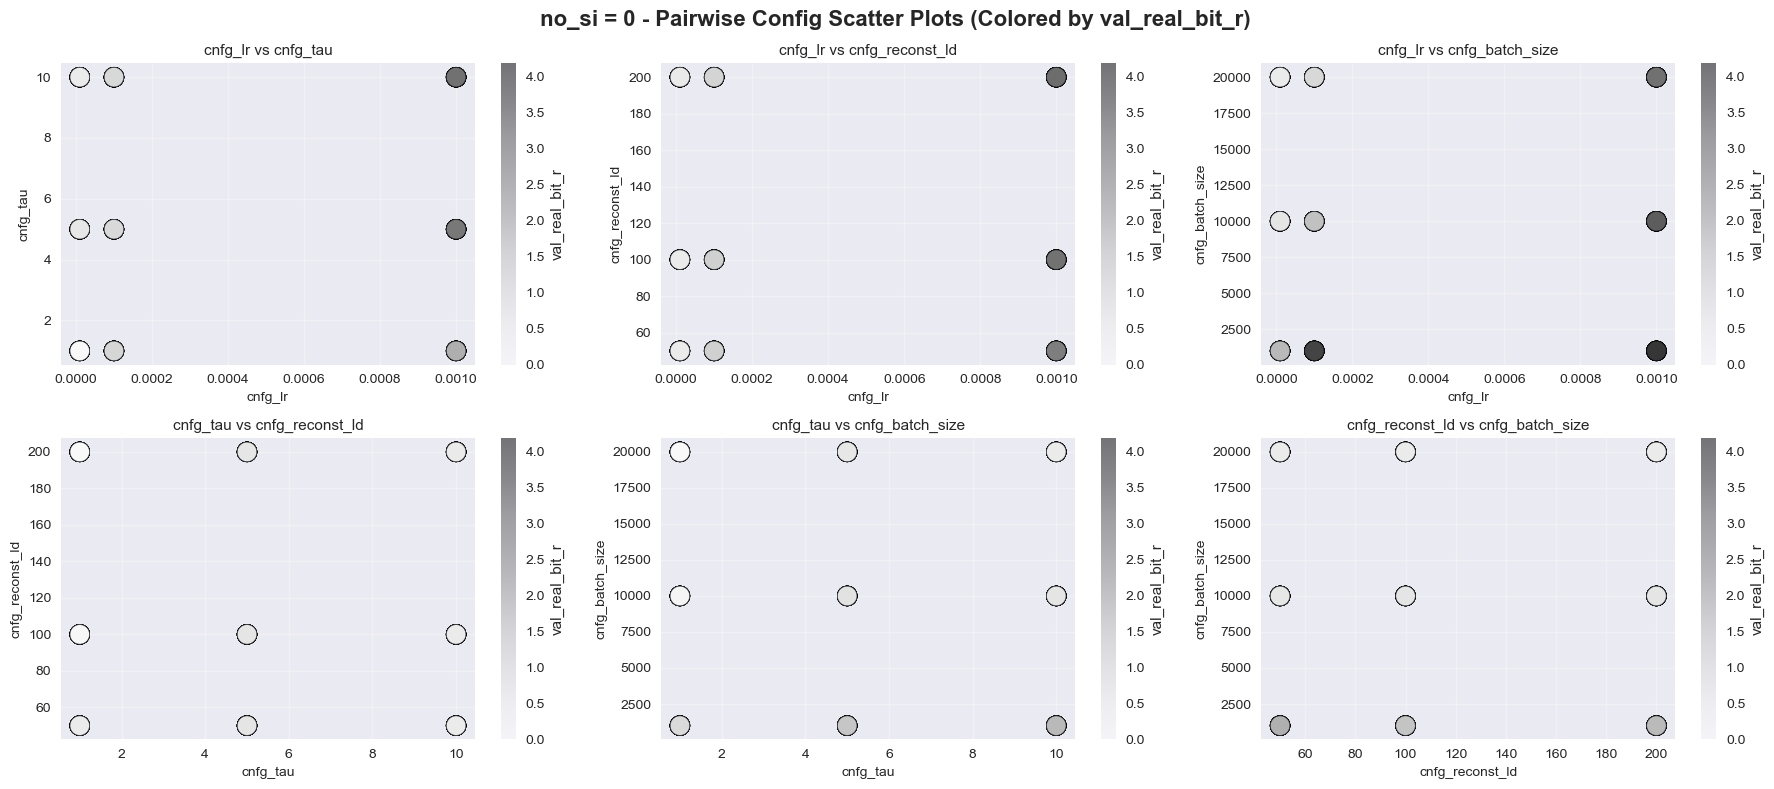

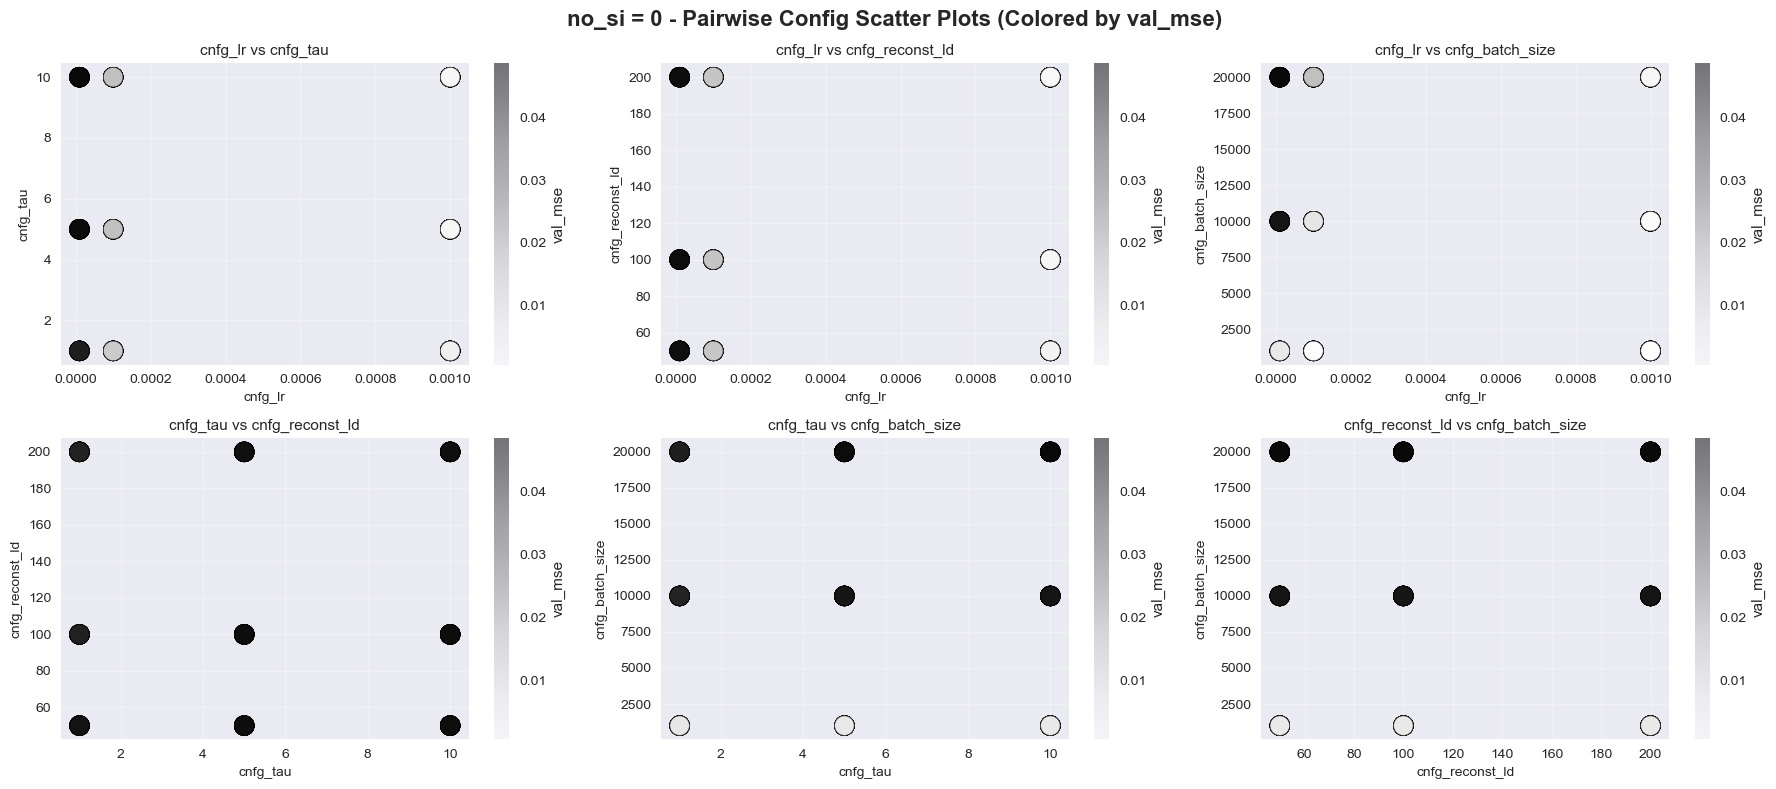


Creating pairwise scatter plots for no_si = 1...
Found 6 configuration pairs for no_si = 1: ['cnfg_lr', 'cnfg_tau', 'cnfg_reconst_ld', 'cnfg_batch_size']


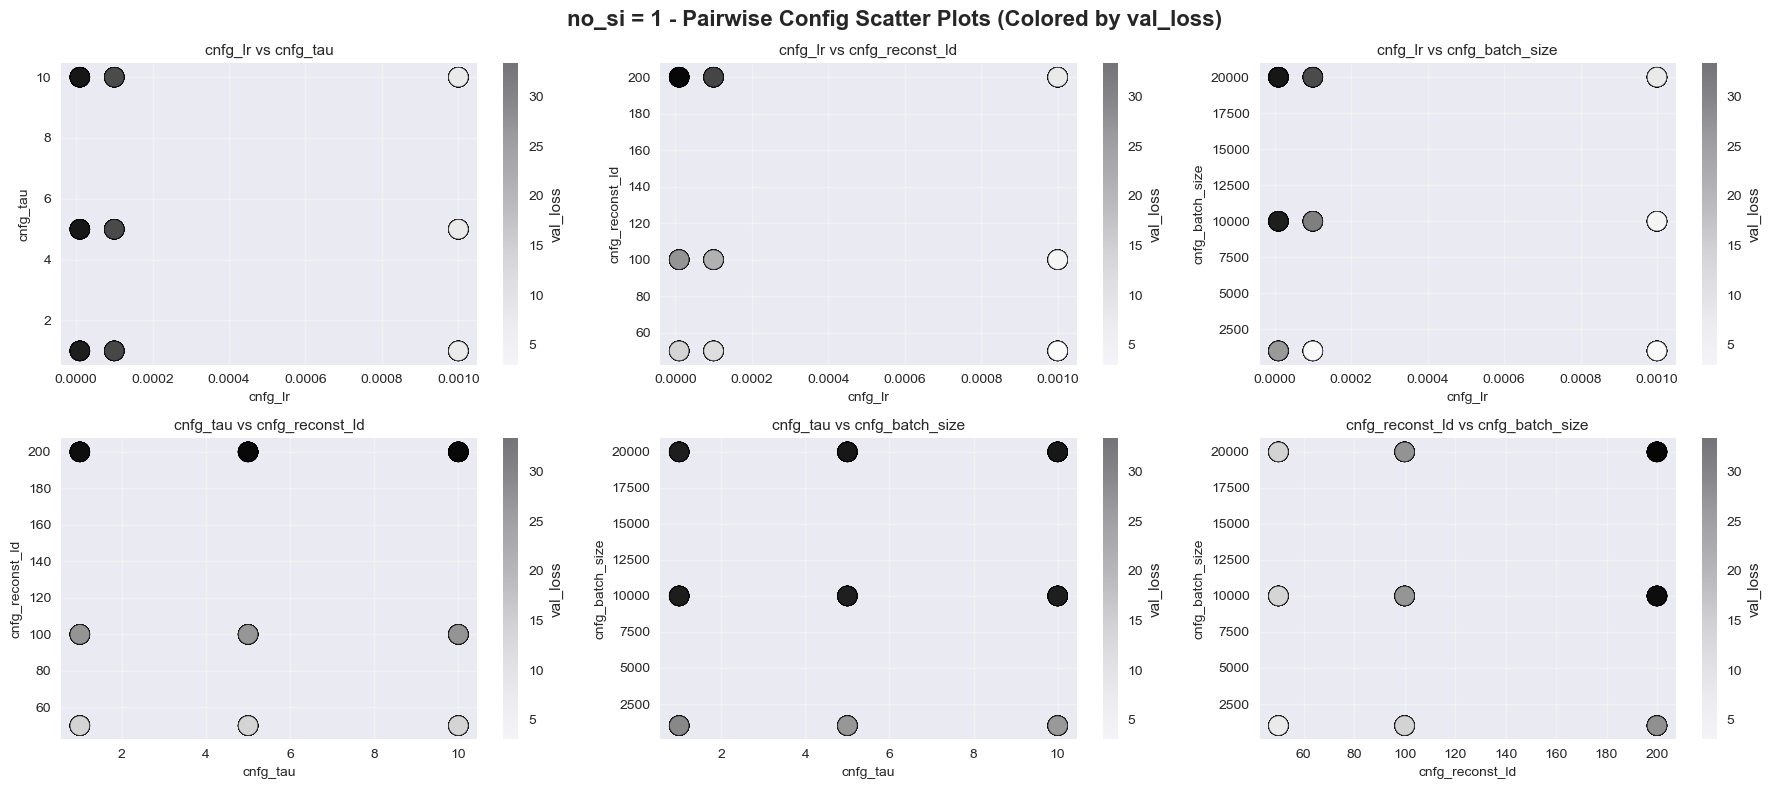

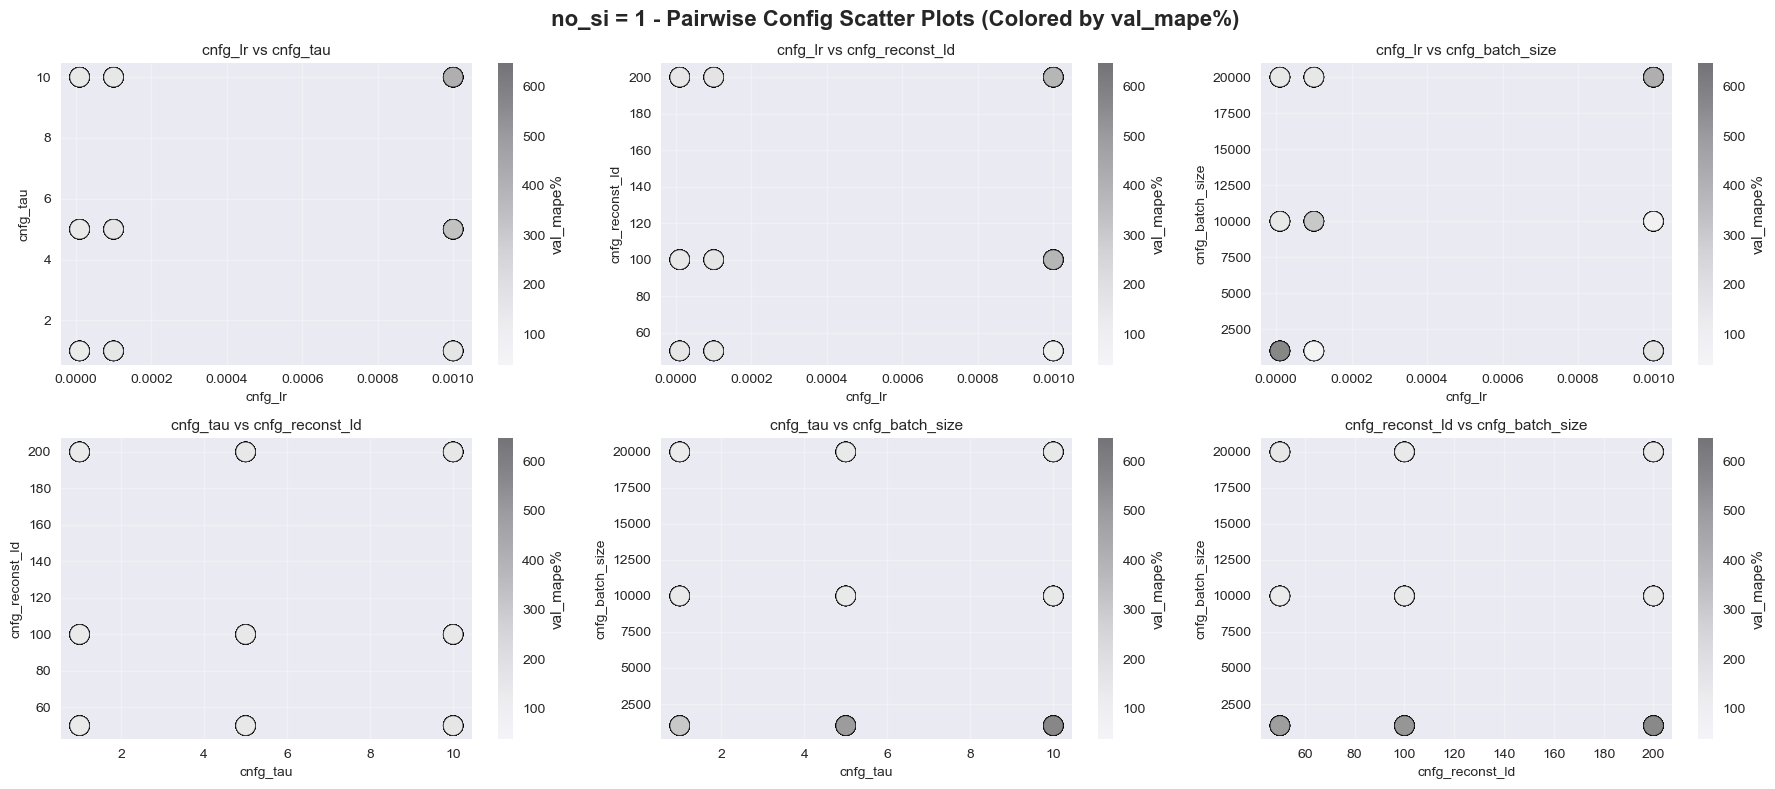

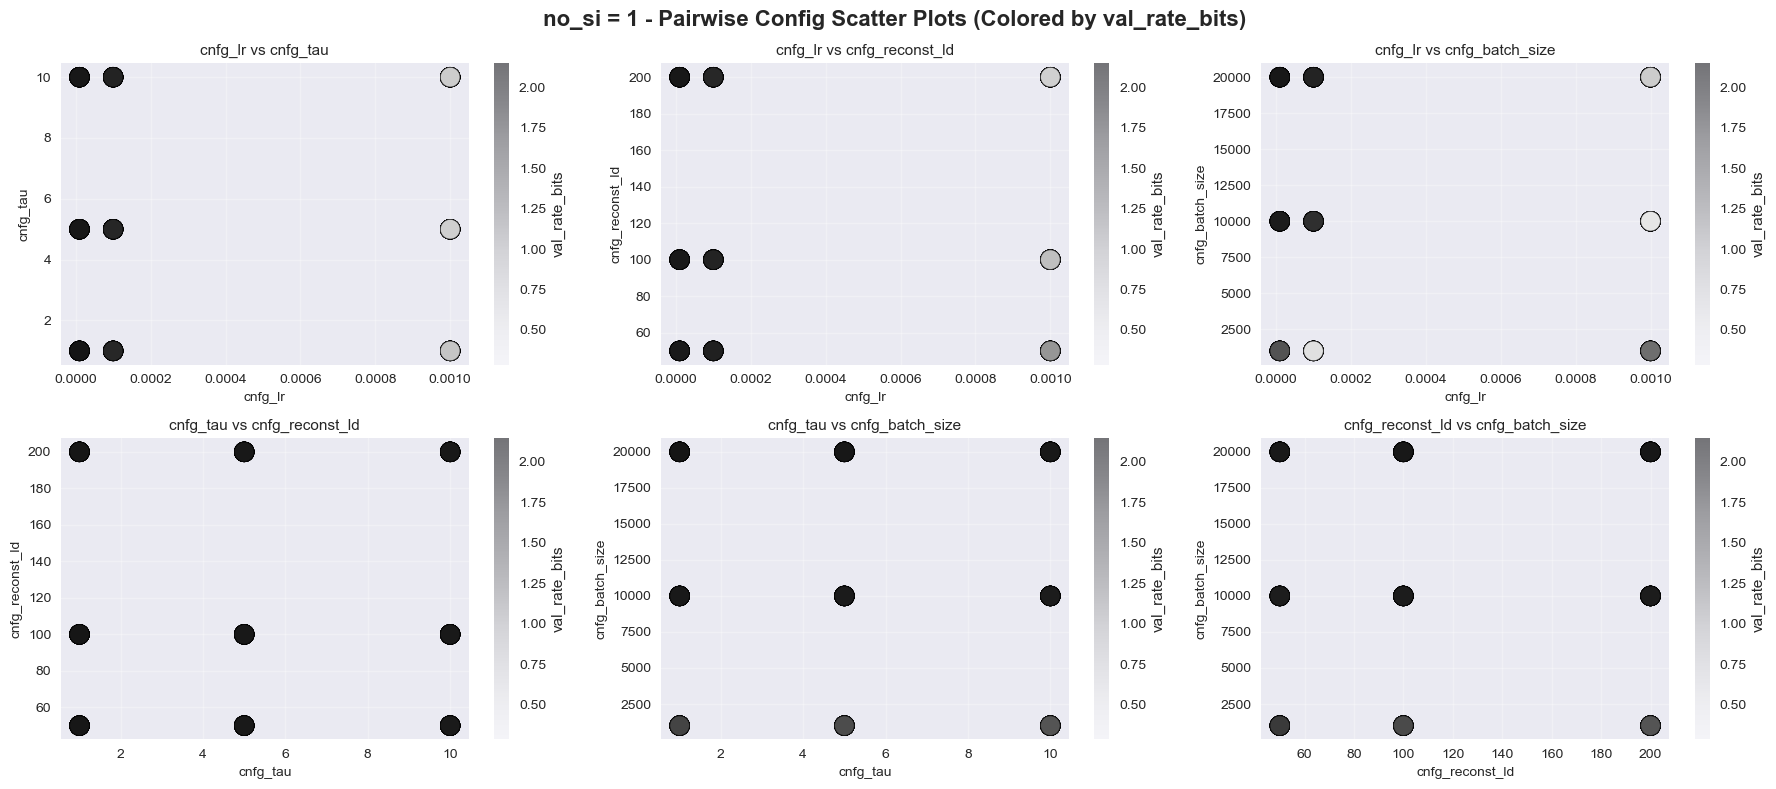

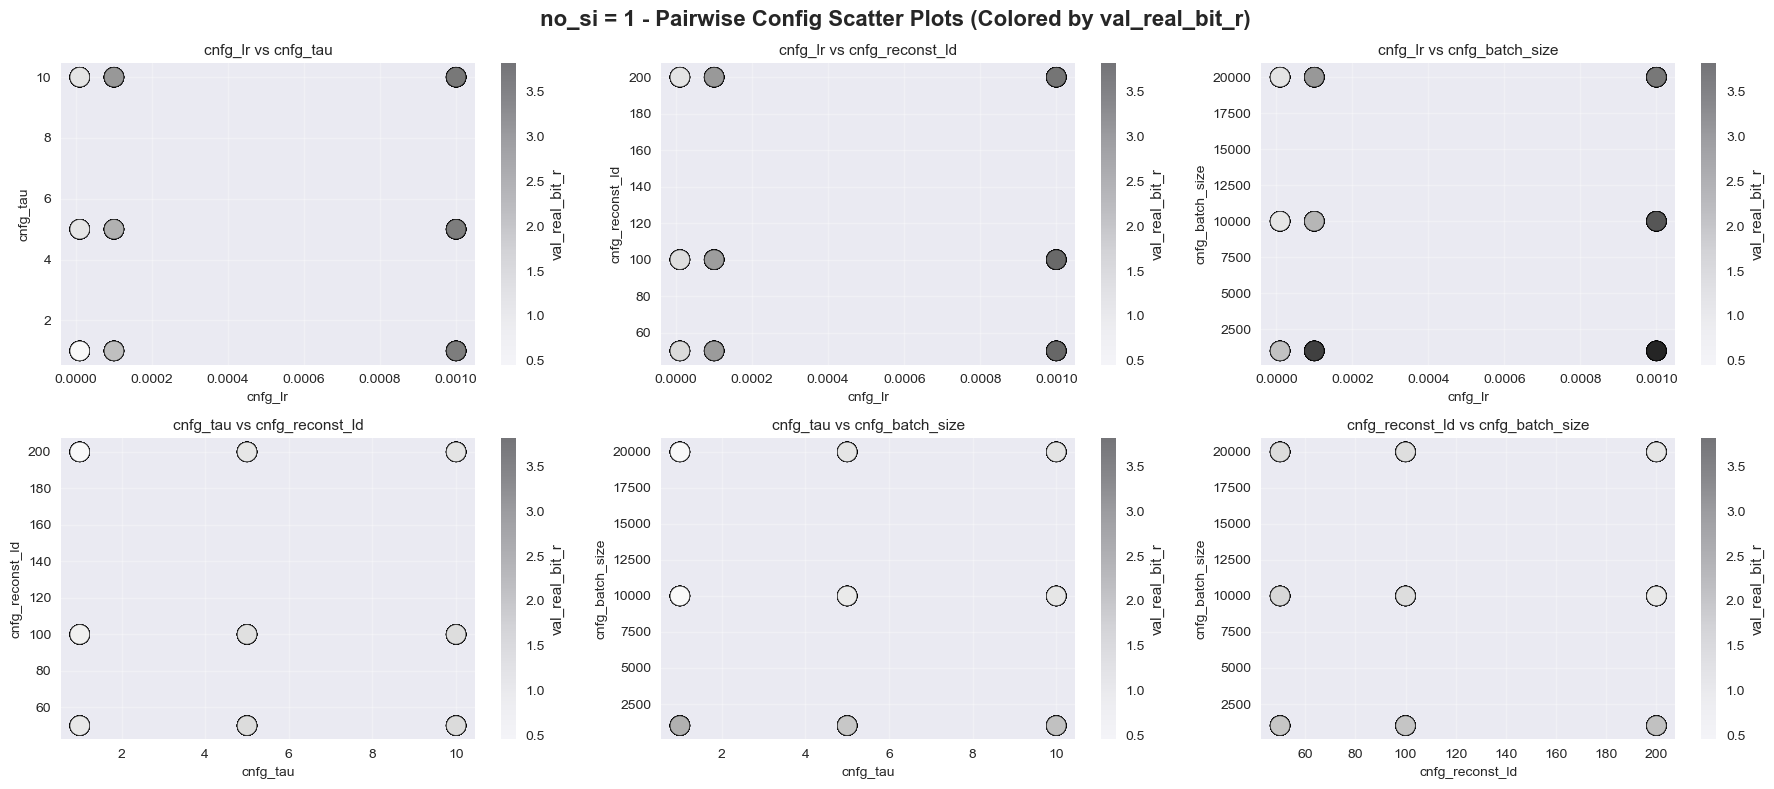

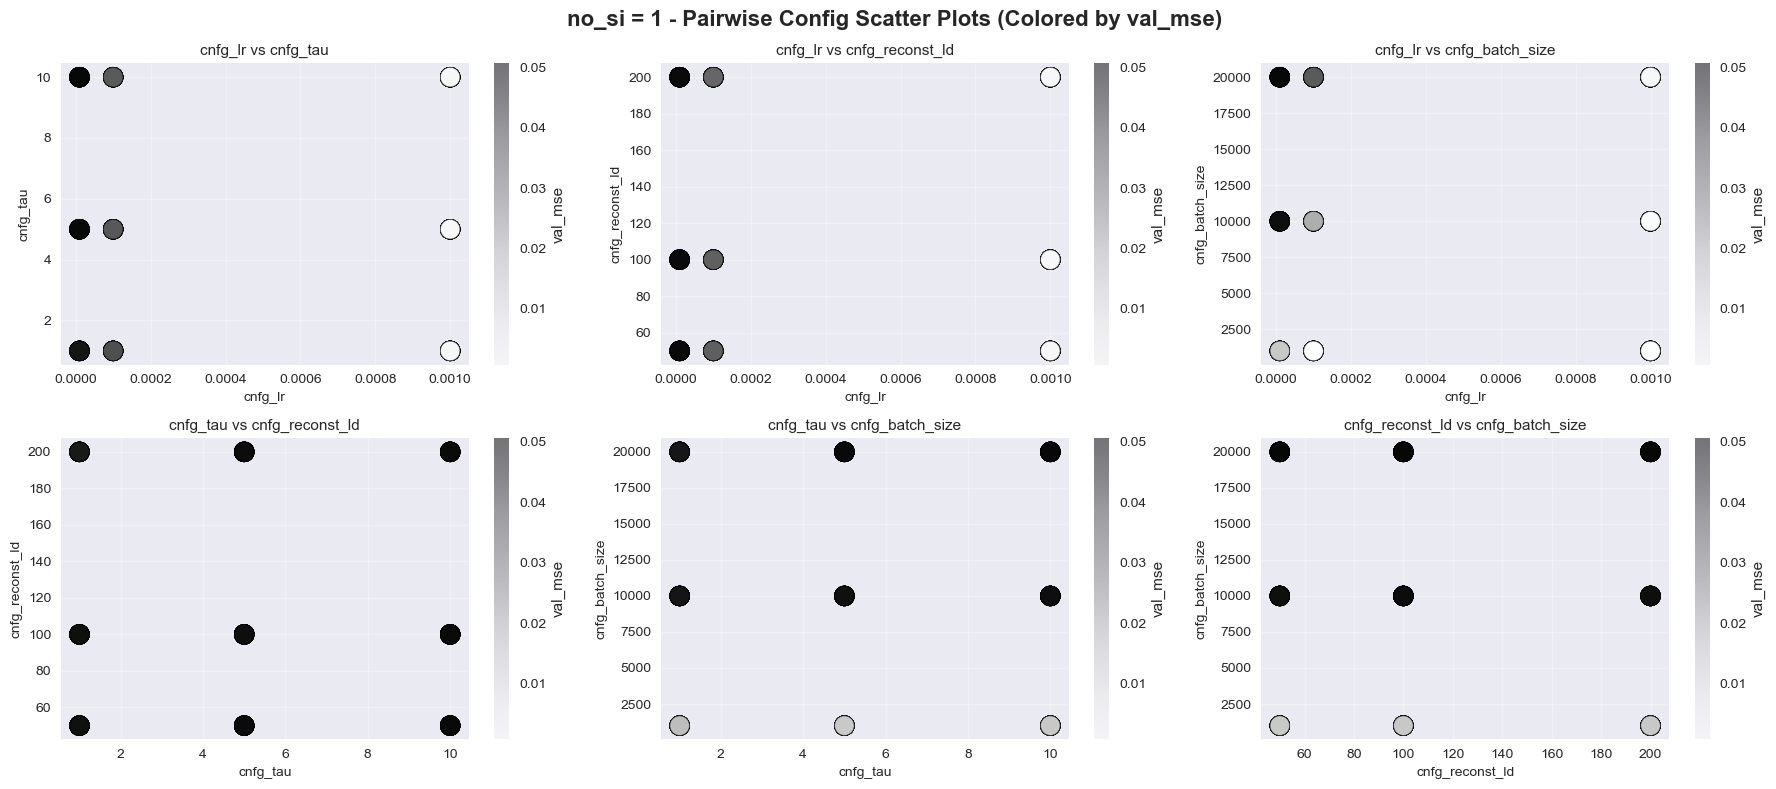

In [32]:
def create_pairwise_scatter_plots(configs, metrics, title_prefix, max_pairs=6):
    """Create pairwise scatter plots of configurations with metric coloring"""
    
    # Get configuration pairs (only from varying configs within this subset)
    subset_varying_configs = [col for col in config_cols if col in configs.columns and configs[col].nunique() > 1]
    config_pairs = list(combinations(subset_varying_configs, 2))
    
    # Limit number of pairs to display
    config_pairs = config_pairs[:max_pairs]
    
    n_pairs = len(config_pairs)
    
    if n_pairs == 0:
        print(f"No varying configuration pairs found for {title_prefix}")
        return
    
    print(f"Found {n_pairs} configuration pairs for {title_prefix}: {subset_varying_configs}")
    
    # Create subplots for each metric
    for metric_idx, metric in enumerate(metric_cols):
        # Calculate grid size based on number of pairs
        cols = min(3, n_pairs)
        rows = (n_pairs + cols - 1) // cols
        
        fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4*rows))
        fig.suptitle(f'{title_prefix} - Pairwise Config Scatter Plots (Colored by {metric})', fontsize=16, fontweight='bold')
        
        # Handle single subplot case
        if n_pairs == 1:
            axes = [axes]
        elif rows == 1:
            axes = axes if hasattr(axes, '__len__') else [axes]
        else:
            axes = axes.flatten()
        
        for pair_idx, (config1, config2) in enumerate(config_pairs):
            ax = axes[pair_idx]
            
            # Create scatter plot
            scatter = ax.scatter(configs[config1],
                               configs[config2],
                               c=metrics[metric],
                               alpha=0.5,
                               s=200,
                               # cmap='viridis',
                               edgecolors='black',
                               linewidth=0.5)
            
            ax.set_xlabel(config1, fontsize=10)
            ax.set_ylabel(config2, fontsize=10)
            ax.set_title(f'{config1} vs {config2}', fontsize=11)
            ax.grid(True, alpha=0.3)
            
            # Add colorbar
            plt.colorbar(scatter, ax=ax, label=metric)
        
        # Hide unused subplots
        for idx in range(len(config_pairs), len(axes)):
            axes[idx].set_visible(False)
        
        plt.tight_layout()
        plt.show()

# Create pairwise scatter plots for both no_si values
print("Creating pairwise scatter plots for no_si = 0...")
create_pairwise_scatter_plots(configs_0, metrics_0, "no_si = 0")

print("\nCreating pairwise scatter plots for no_si = 1...")
create_pairwise_scatter_plots(configs_1, metrics_1, "no_si = 1")

## 6. Metric vs Configuration Scatter Plots

Creating metric vs configuration plots for no_si = 0...
Found 4 varying configurations for no_si = 0: ['cnfg_lr', 'cnfg_tau', 'cnfg_reconst_ld', 'cnfg_batch_size']


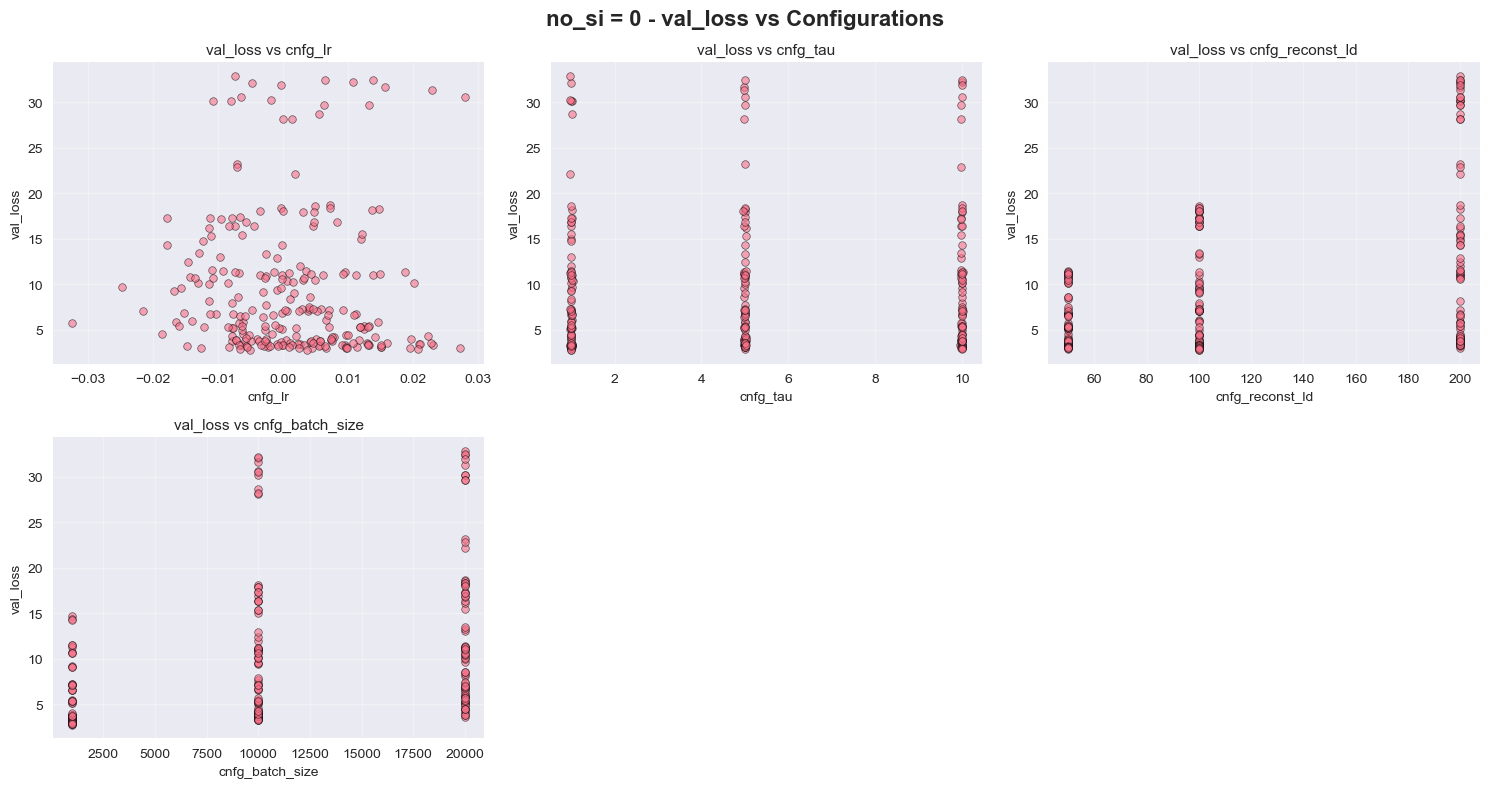

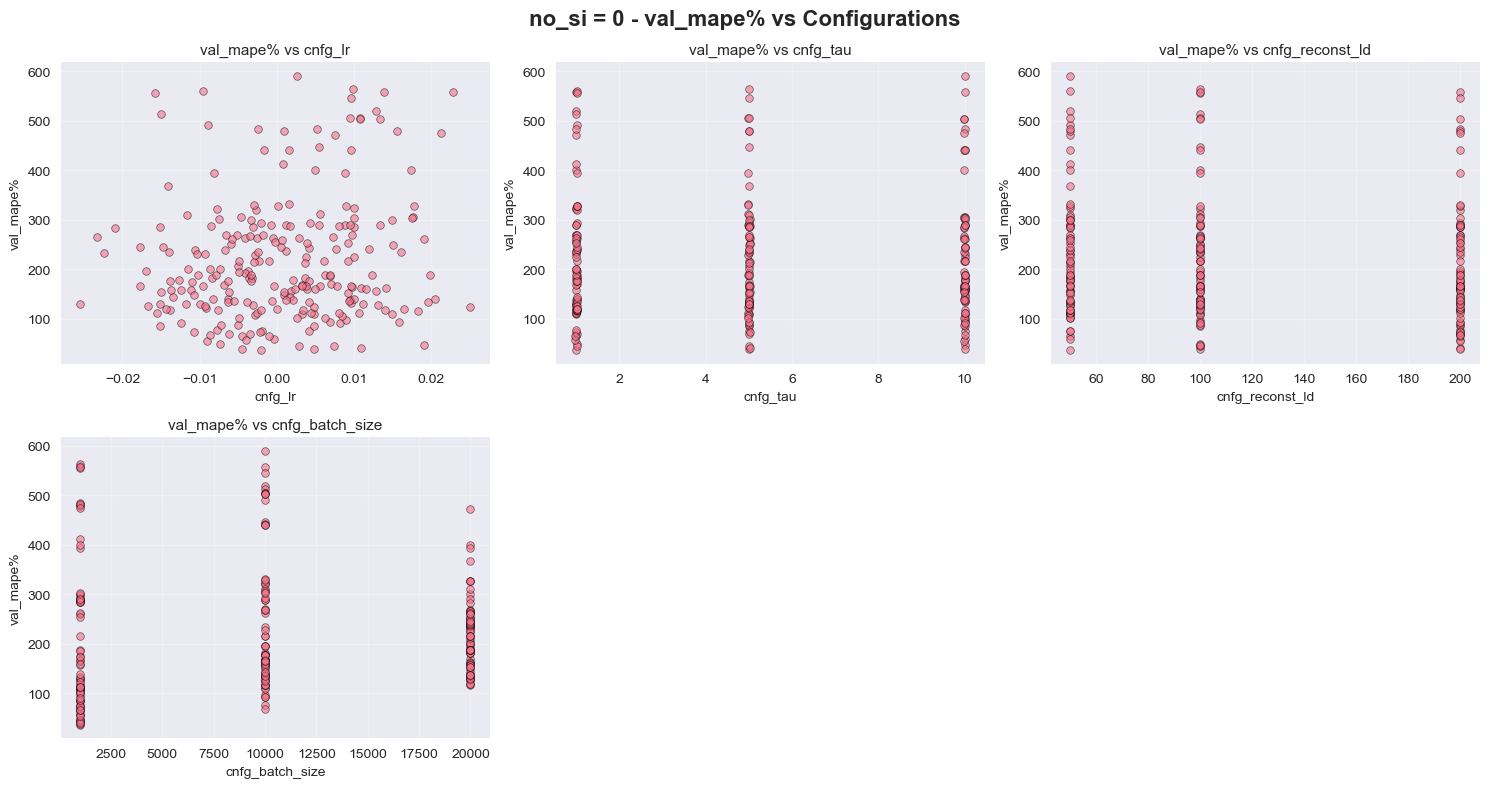

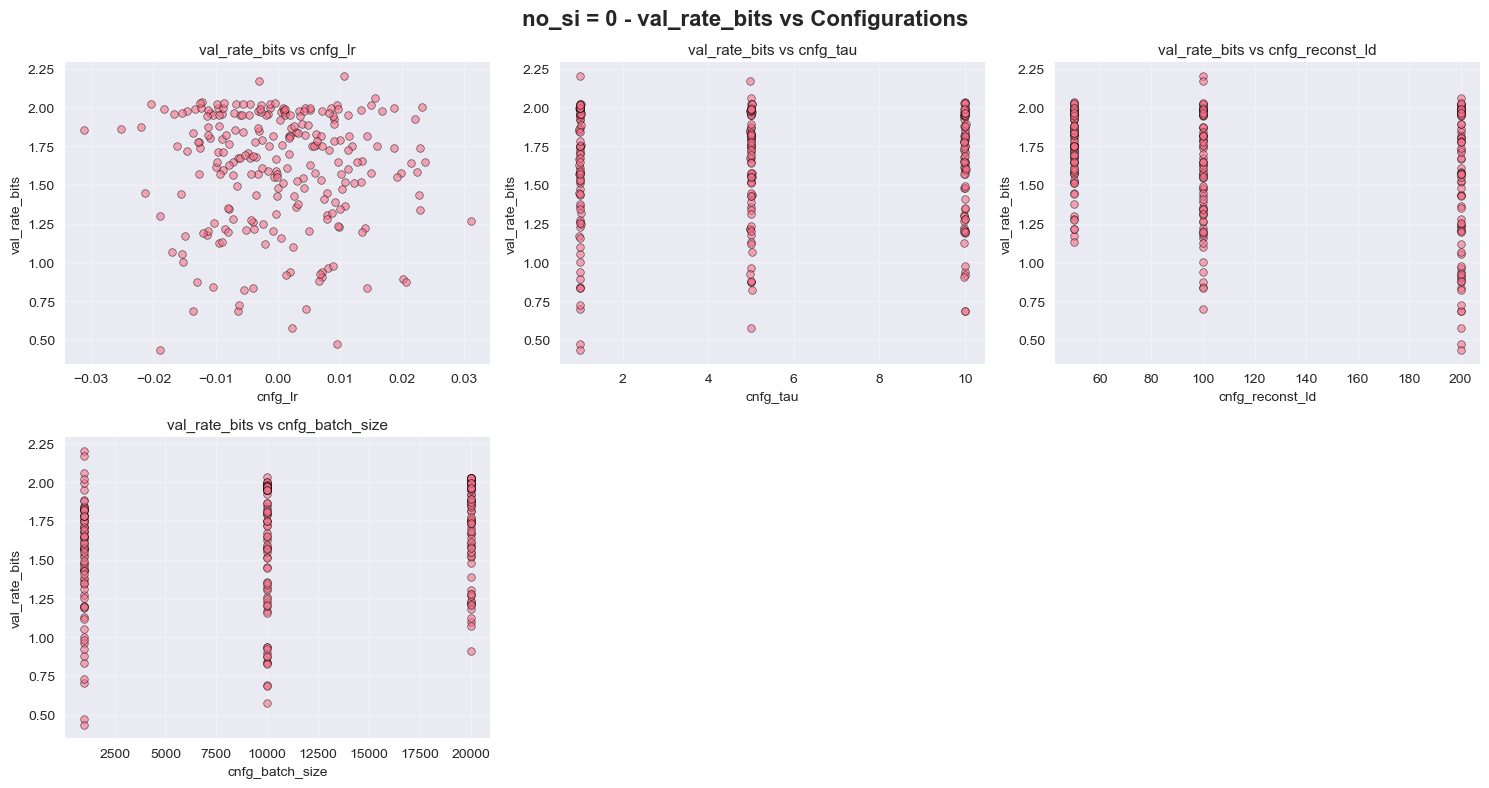

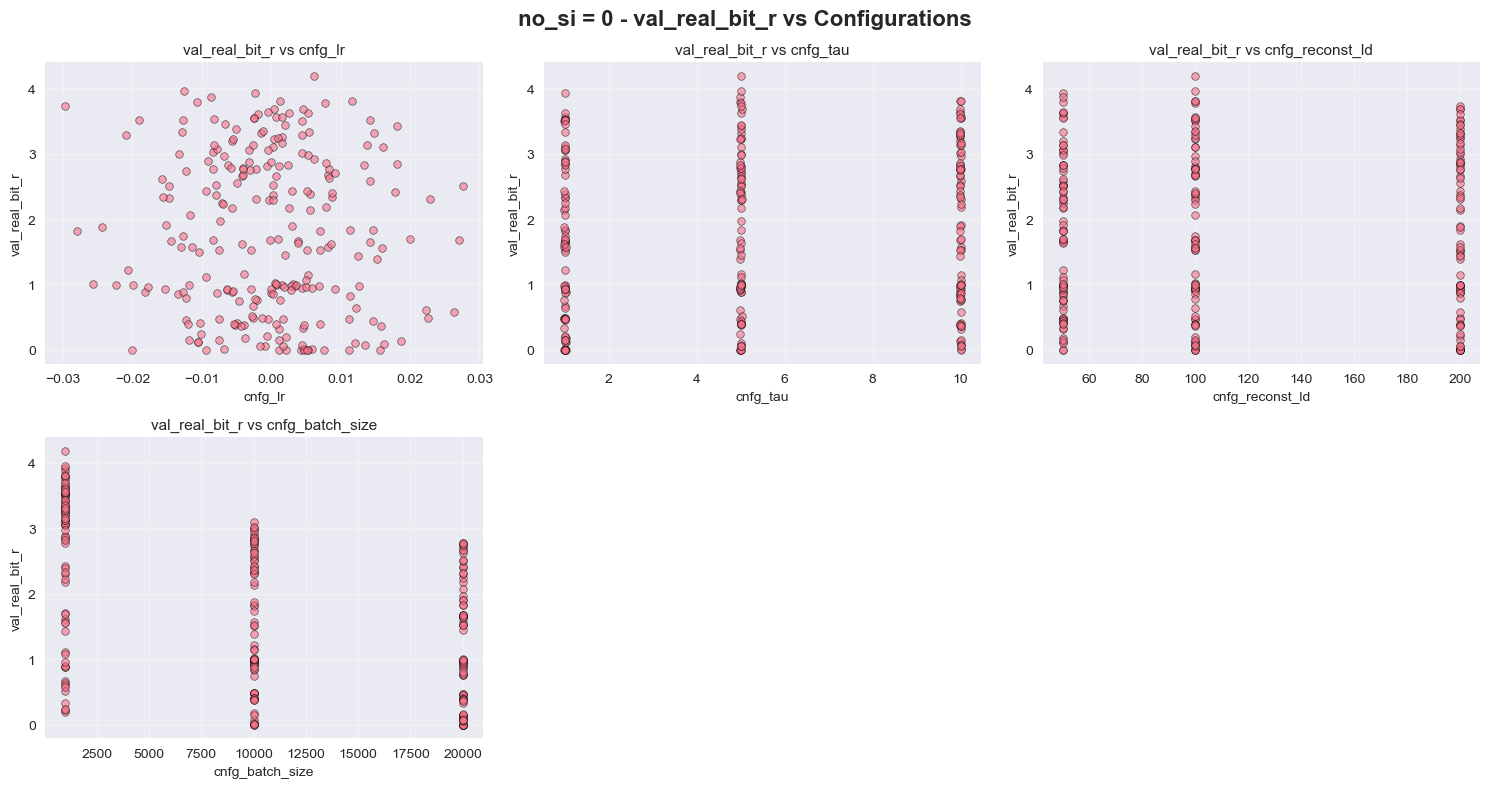

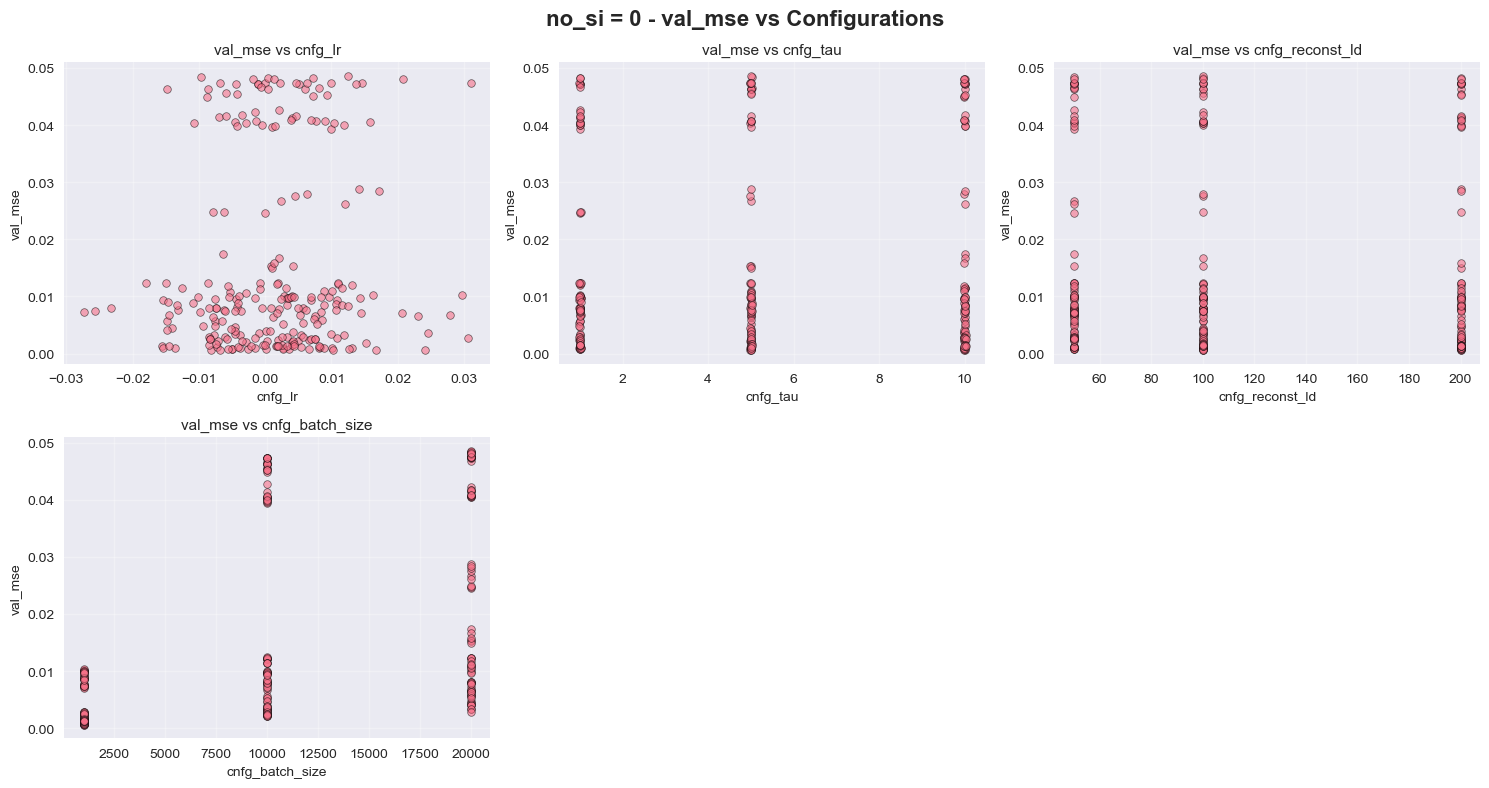


Creating metric vs configuration plots for no_si = 1...
Found 4 varying configurations for no_si = 1: ['cnfg_lr', 'cnfg_tau', 'cnfg_reconst_ld', 'cnfg_batch_size']


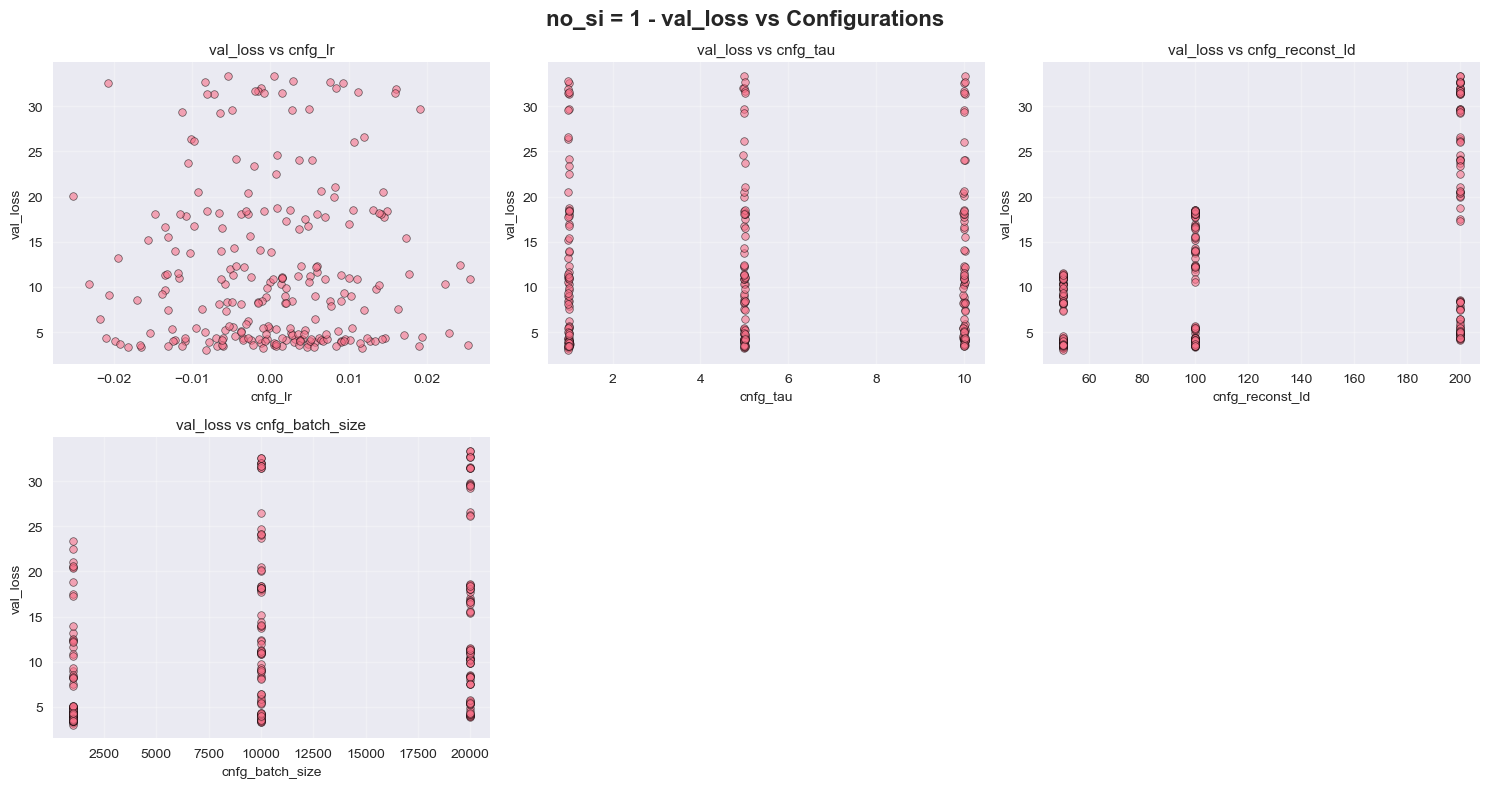

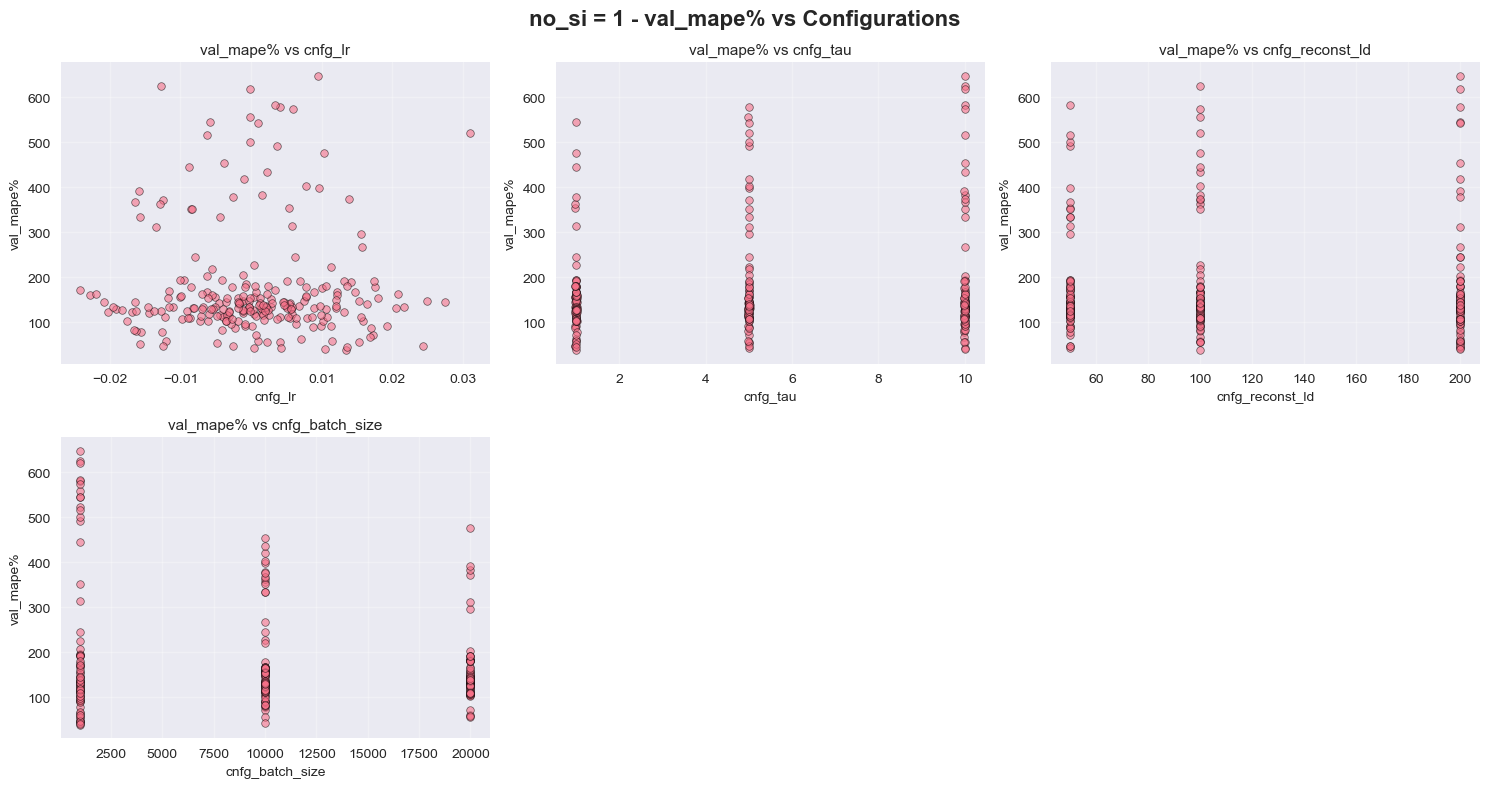

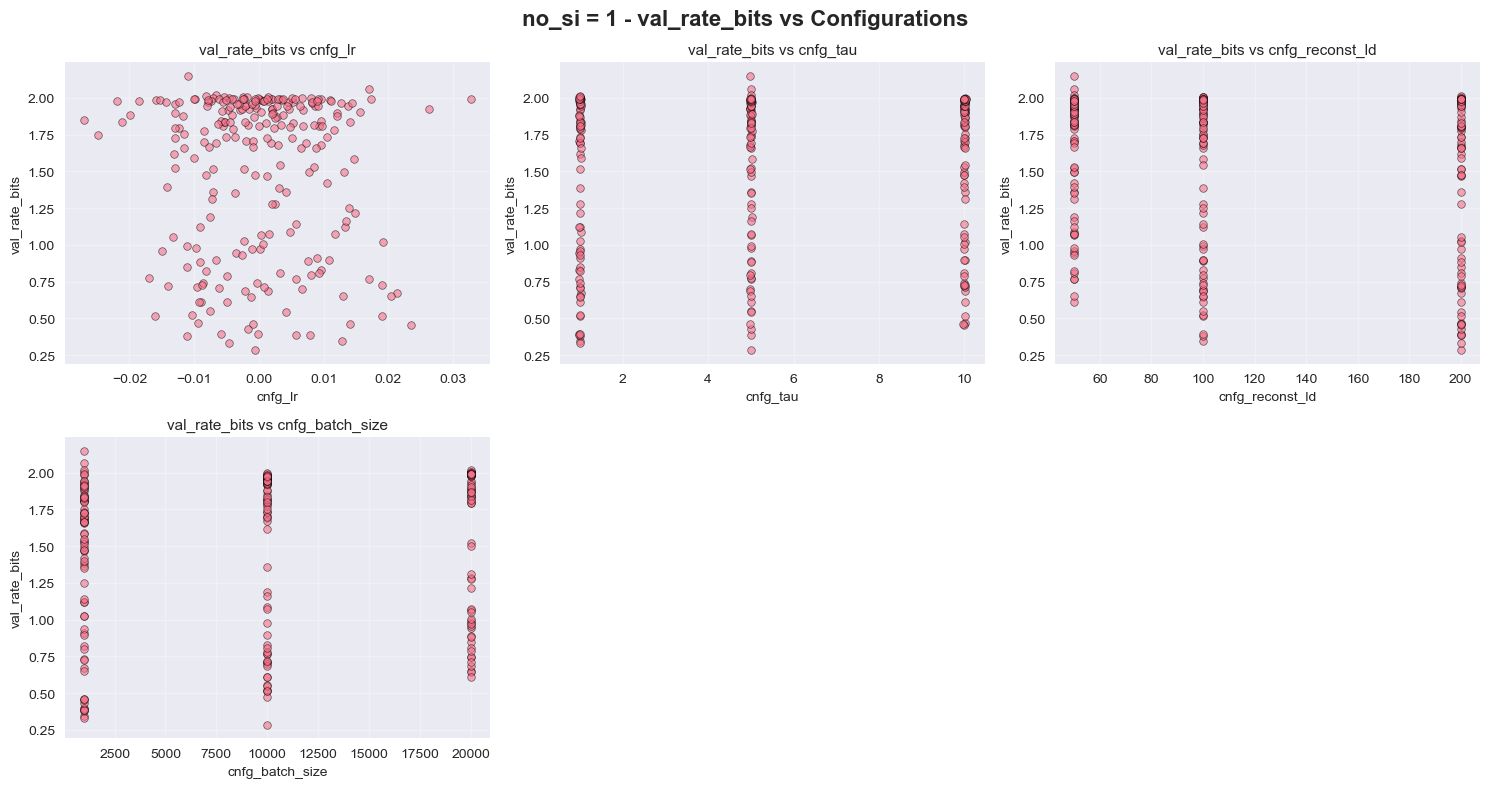

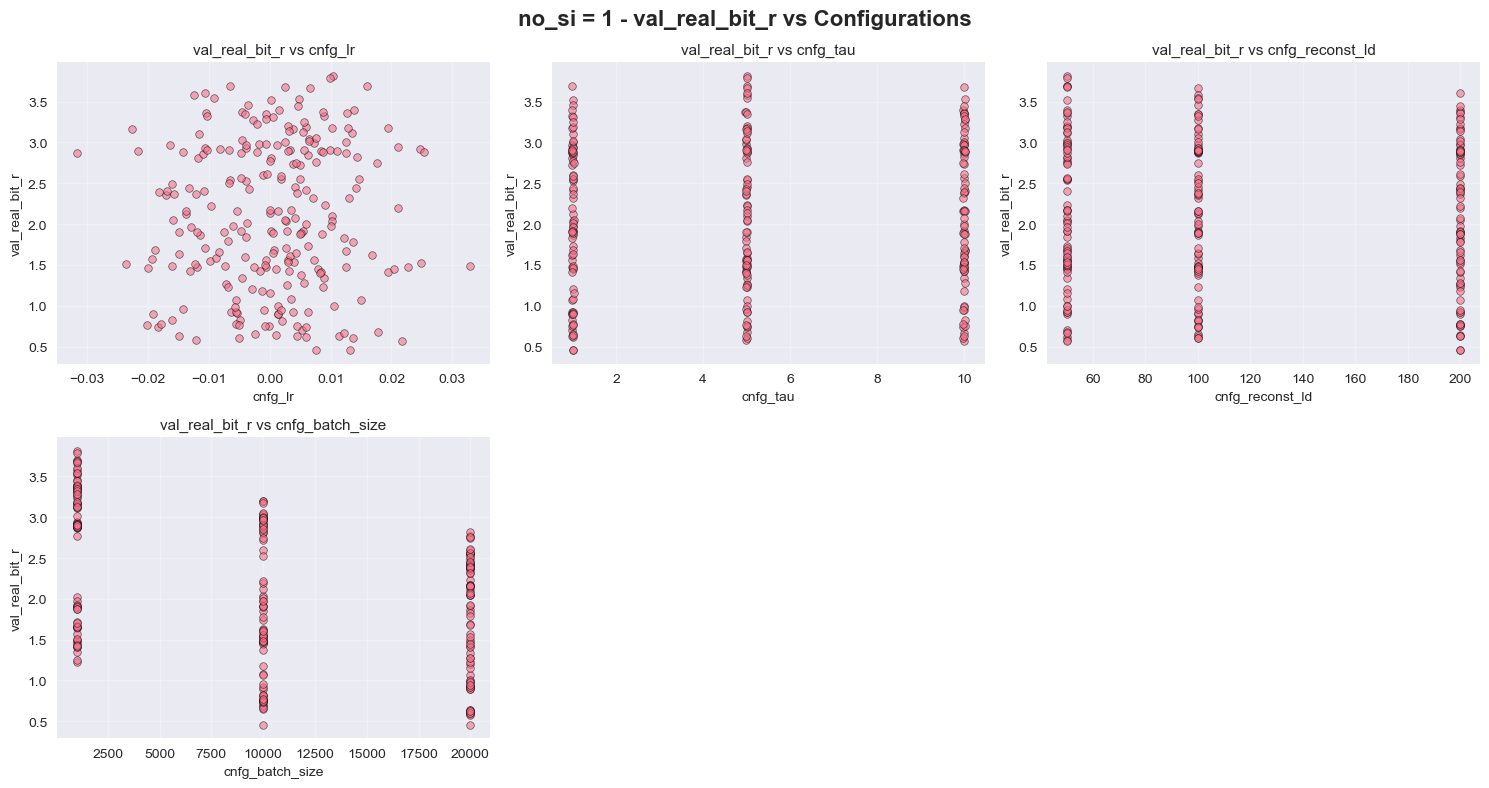

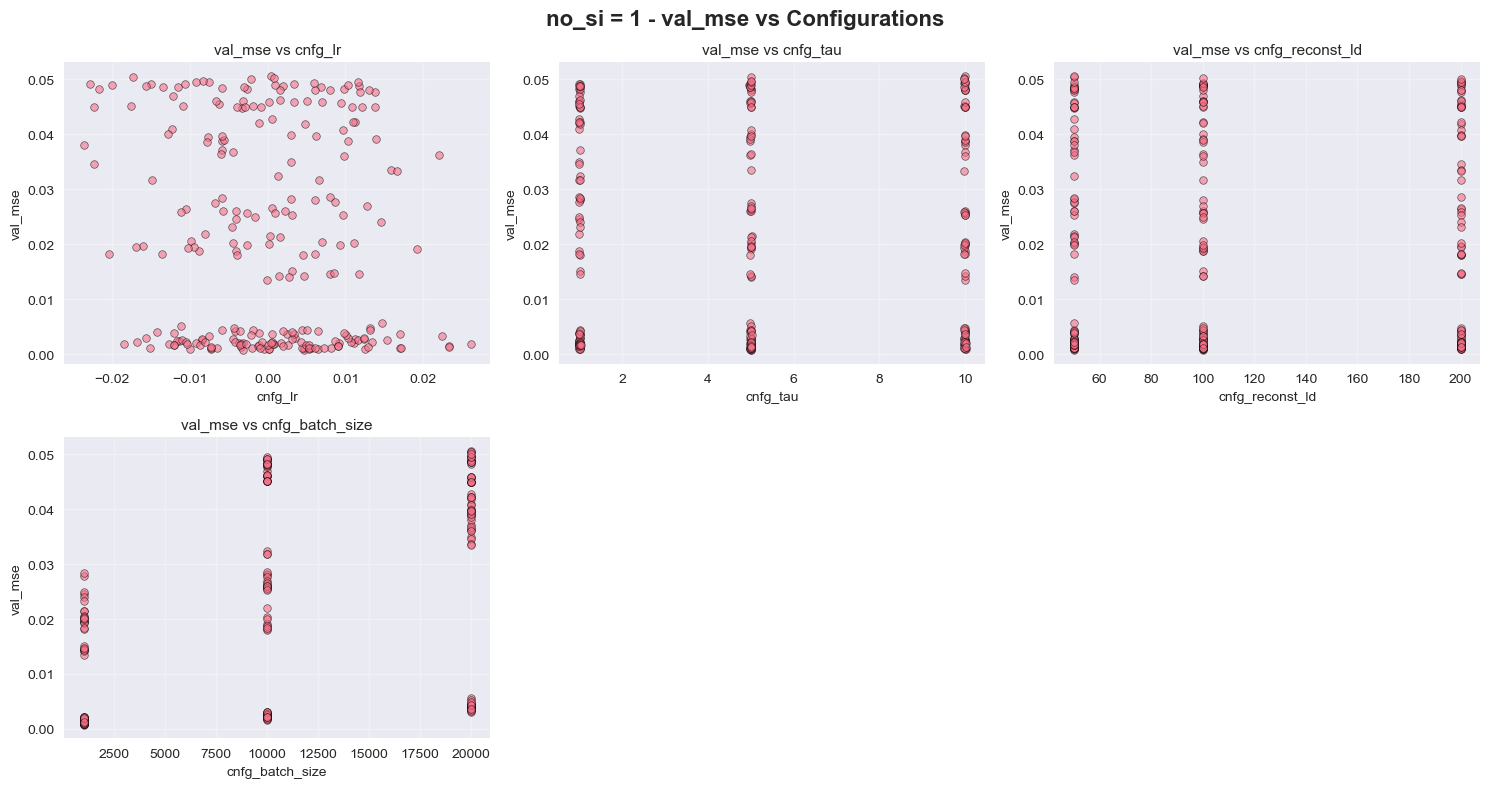

In [33]:
def create_metric_vs_config_plots(configs, metrics, title_prefix):
    """Create scatter plots for each metric vs each configuration"""
    
    # Get varying configurations within this subset
    subset_varying_configs = [col for col in config_cols if col in configs.columns and configs[col].nunique() > 1]
    
    if not subset_varying_configs:
        print(f"No varying configurations found for {title_prefix}")
        return
    
    n_configs = len(subset_varying_configs)
    print(f"Found {n_configs} varying configurations for {title_prefix}: {subset_varying_configs}")
    
    # Create plots for each metric
    for metric in metric_cols:
        # Calculate subplot grid
        cols = min(3, n_configs)
        rows = (n_configs + cols - 1) // cols
        
        fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
        fig.suptitle(f'{title_prefix} - {metric} vs Configurations', fontsize=16, fontweight='bold')
        
        # Handle different subplot configurations
        if n_configs == 1:
            axes = [axes]
        elif rows == 1:
            axes = axes if hasattr(axes, '__len__') else [axes]
        else:
            axes = axes.flatten()
        
        for config_idx, config in enumerate(subset_varying_configs):
            ax = axes[config_idx] if n_configs > 1 else axes[0]
            
            # Create scatter plot with jitter for categorical variables
            x_values = configs[config]
            y_values = metrics[metric]
            
            # Add slight jitter if x values are discrete
            if configs[config].nunique() <= 10:
                x_jitter = x_values + np.random.normal(0, 0.01, len(x_values))
            else:
                x_jitter = x_values
            
            ax.scatter(x_jitter, y_values, alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
            
            ax.set_xlabel(config, fontsize=10)
            ax.set_ylabel(metric, fontsize=10)
            ax.set_title(f'{metric} vs {config}', fontsize=11)
            ax.grid(True, alpha=0.3)
            
            # Add trend line if continuous variable
            if configs[config].nunique() > 10:
                z = np.polyfit(x_values, y_values, 1)
                p = np.poly1d(z)
                ax.plot(x_values.sort_values(), p(x_values.sort_values()), "r--", alpha=0.8, linewidth=2)
        
        # Hide unused subplots
        if n_configs > 1:
            for idx in range(n_configs, len(axes)):
                axes[idx].set_visible(False)
        
        plt.tight_layout()
        plt.show()

# Create metric vs configuration plots for both no_si values
print("Creating metric vs configuration plots for no_si = 0...")
create_metric_vs_config_plots(configs_0, metrics_0, "no_si = 0")

print("\nCreating metric vs configuration plots for no_si = 1...")
create_metric_vs_config_plots(configs_1, metrics_1, "no_si = 1")

## Summary and Insights

This notebook provides three types of visualizations for analyzing hyperparameter grid search results:

### 1. Correlation Matrix
- Shows the correlation between each hyperparameter (configuration) and each metric
- Helps identify which hyperparameters have the strongest influence on performance metrics
- Separate matrices for `no_si = 0` and `no_si = 1` since these represent different experimental conditions

### 2. Pairwise Configuration Scatter Plots
- Visualizes relationships between pairs of hyperparameters
- Each point represents one experiment run
- Color coding shows metric values, helping identify optimal parameter combinations
- Alpha transparency helps with overlapping points

### 3. Metric vs Configuration Scatter Plots
- Individual plots for each metric against each hyperparameter
- Shows direct relationships between single parameters and performance
- Trend lines added for continuous variables to show overall trends
- Jitter added for discrete variables to better visualize point distributions

### Key Observations:
- Run the notebook to see specific insights about parameter importance
- Look for strong correlations in the correlation matrix
- Identify parameter combinations that yield optimal metric values in scatter plots
- Compare patterns between `no_si = 0` and `no_si = 1` conditions

In [35]:
# Get the top 3 configs (and metrics) based on val_mape%
# First filter by config batch_size to be 20000, then find best performing configs

print("=== TOP PERFORMING CONFIGURATIONS ANALYSIS ===\n")

# Check if batch_size filter is applicable
if 'cnfg_batch_size' in df_median.columns:
    batch_size_values = df_median['cnfg_batch_size'].unique()
    print(f"Available batch_size values: {batch_size_values}")
    
    if 1000 in batch_size_values:
        # Filter by batch_size = 20000
        filtered_df = df_median[df_median['cnfg_batch_size'] == 1000].copy()
        print(f"Rows with batch_size = 20000: {len(filtered_df)}")
    else:
        print("batch_size = 20000 not found. Using all data.")
        filtered_df = df_median.copy()
else:
    print("cnfg_batch_size column not found. Using all data.")
    filtered_df = df_median.copy()

print(f"Total rows for analysis: {len(filtered_df)}")

# Analyze for each no_si value separately
for no_si_val in [0, 1]:
    print(f"\n{'='*50}")
    print(f"TOP 3 CONFIGURATIONS FOR no_si = {no_si_val}")
    print(f"{'='*50}")
    
    subset = filtered_df[filtered_df['no_si'] == no_si_val].copy()
    
    if len(subset) == 0:
        print(f"No data available for no_si = {no_si_val}")
        continue
    
    # Sort by val_mape% (ascending - lower is better)
    top_configs = subset.nsmallest(3, 'val_mape%')
    
    print(f"Found {len(subset)} configurations for no_si = {no_si_val}")
    print(f"Showing top {min(3, len(top_configs))} best performing:\n")
    
    for idx, (_, row) in enumerate(top_configs.iterrows(), 1):
        print(f"--- RANK {idx} ---")
        print(f"Sample ID: {row['sample_id']}")
        
        # Show all metrics
        print("Metrics:")
        for metric in metric_cols:
            print(f"  {metric}: {row[metric]:.6f}")
        
        # Show varying configurations only
        print("Configuration:")
        for config in config_cols:
            if config in row.index:
                print(f"  {config}: {row[config]}")
        print()

# Overall best configuration across both no_si values
print(f"\n{'='*60}")
print("OVERALL BEST CONFIGURATION (lowest val_mape%)")
print(f"{'='*60}")

best_overall = filtered_df.nsmallest(1, 'val_mape%').iloc[0]
print(f"Sample ID: {best_overall['sample_id']}")
print(f"no_si: {best_overall['no_si']}")

print("Metrics:")
for metric in metric_cols:
    print(f"  {metric}: {best_overall[metric]:.6f}")

print("Configuration:")
for config in config_cols:
    if config in best_overall.index:
        print(f"  {config}: {best_overall[config]}")

# Summary statistics
print(f"\n{'='*50}")
print("SUMMARY STATISTICS")
print(f"{'='*50}")

for no_si_val in [0, 1]:
    subset = filtered_df[filtered_df['no_si'] == no_si_val]
    if len(subset) > 0:
        print(f"\nno_si = {no_si_val}:")
        print(f"  Best val_mape%: {subset['val_mape%'].min():.6f}")
        print(f"  Worst val_mape%: {subset['val_mape%'].max():.6f}")
        print(f"  Mean val_mape%: {subset['val_mape%'].mean():.6f}")
        print(f"  Median val_mape%: {subset['val_mape%'].median():.6f}")
        print(f"  Standard deviation: {subset['val_mape%'].std():.6f}")

print(f"\nAnalysis complete! 🎯")

=== TOP PERFORMING CONFIGURATIONS ANALYSIS ===

Available batch_size values: [ 1000 10000 20000]
Rows with batch_size = 20000: 162
Total rows for analysis: 162

TOP 3 CONFIGURATIONS FOR no_si = 0
Found 81 configurations for no_si = 0
Showing top 3 best performing:

--- RANK 1 ---
Sample ID: config_1_sample_1
Metrics:
  val_loss: 3.349525
  val_mape%: 36.666748
  val_rate_bits: 1.951440
  val_real_bit_r: 3.624537
  val_mse: 0.000919
Configuration:
  cnfg_lr: 0.001
  cnfg_tau: 1.0
  cnfg_reconst_ld: 50.0
  cnfg_batch_size: 1000

--- RANK 2 ---
Sample ID: config_21_sample_0
Metrics:
  val_loss: 3.536482
  val_mape%: 37.746986
  val_rate_bits: 1.817323
  val_real_bit_r: 4.184308
  val_mse: 0.000639
Configuration:
  cnfg_lr: 0.001
  cnfg_tau: 5.0
  cnfg_reconst_ld: 100.0
  cnfg_batch_size: 1000

--- RANK 3 ---
Sample ID: config_41_sample_0
Metrics:
  val_loss: 3.760927
  val_mape%: 39.394207
  val_rate_bits: 1.814789
  val_real_bit_r: 3.688507
  val_mse: 0.000777
Configuration:
  cnfg_lr: 0